# Entregável 9 — Seleção de Atributos

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Abril e Maio de 2026

---

## Objetivo

Este notebook realiza a **Seleção de Atributos** (*feature selection*) sobre o dataset de features engenhadas produzido no Entregável 7 (`features_engineered.parquet`), com o propósito de identificar e reter o subconjunto de features com maior poder discriminativo para o problema de classificação de ECG.

A seleção de atributos é uma etapa distinta — e complementar — à redução de dimensionalidade realizada no Entregável 8. Enquanto o PCA projeta o espaço original em novas direções abstratas (componentes), a seleção de atributos mantém as variáveis originais, preservando interpretabilidade clínica. Cada feature selecionada continua sendo, por exemplo, "potência espectral do QRS na derivação V5" — e não uma combinação linear de centenas de outras.

Além disso, a seleção reduz o risco de **overfitting**, remove features redundantes que aumentam custo computacional sem agregar informação nova, e melhora a estabilidade dos modelos de classificação ao eliminar dimensões com alta variância, mas baixa relevância discriminativa.

Três famílias de métodos são exploradas neste entregável:

1. **Filter Methods:** avaliam features individualmente com base em critérios estatísticos — rápidos e independentes do classificador. Aplicamos **ANOVA F-score**, **Informação Mútua** e **ReliefF**.
2. **Wrapper Methods:** avaliam subconjuntos de features treinando um estimador — captura interações entre features. Aplicamos **Sequential Forward Selection (SFS)** e **Sequential Backward Elimination (SBE)**.
3. **Embedded Methods:** a seleção ocorre durante o treinamento do próprio modelo. Aplicamos **LASSO (Regularização L1)** e **Importância por Random Forest**.

Por fim, a validação estatística formal de cada feature é realizada por meio de testes de hipótese, correção para múltiplas comparações e cálculo de effect size — garantindo que a seleção final tenha suporte estatístico rigoroso.

O entregável é organizado em:

1. **Importações, Configurações e Dependências**
2. **Carregamento e Inspeção do Dataset**
3. **Filter Methods**
   - 3.1 ANOVA F-score
   - 3.2 Informação Mútua
   - 3.3 ReliefF
4. **Wrapper Methods**
   - 4.1 Sequential Forward Selection (SFS)
   - 4.2 Sequential Backward Elimination (SBE)
5. **Embedded Methods**
   - 5.1 LASSO (Regularização L1)
   - 5.2 Importância por Random Forest
6. **Validação Estatística por Feature**
   - 6.1 Testes de Hipótese por Feature
   - 6.2 Correção de Múltiplas Comparações
   - 6.3 Effect Size (Cohen's d / Eta-quadrado)
7. **Consolidação e Ranking Final dos Atributos**
8. **Dataset Final Selecionado e Persistência**


---

## 1. Importações, Configurações e Dependências

Bibliotecas específicas deste notebook:

- **`sklearn.feature_selection`:** implementações de filter (f_classif, mutual_info_classif), wrapper (SequentialFeatureSelector) e embedded (SelectFromModel).
- **`sklearn.linear_model.LassoCV`:** LASSO com cross-validation automática do hiperparâmetro λ, evitando ajuste manual de regularização.
- **`sklearn.ensemble.RandomForestClassifier`:** usado como estimador para extração de importância via impureza de Gini — robusto e não-paramétrico.
- **`scipy.stats`:** testes de hipótese por feature (Kruskal-Wallis e Mann-Whitney com todas as comparações par-a-par).
- **`statsmodels.stats.multitest`:** correção de Bonferroni e FDR (Benjamini-Hochberg) para o problema de múltiplas comparações.
- **`skrebate`:** implementação do algoritmo ReliefF para seleção baseada em relevância relacional entre instâncias.


In [54]:
import os
import ast
import gc
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations


# Descomente se necessário:
#!pip install statsmodels skrebate

# Estatística
from scipy.stats import (kruskal, mannwhitneyu, f_oneway,
                         shapiro, levene)
from statsmodels.stats.multitest import multipletests

# Scikit-learn — seleção e modelos
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import (
    f_classif, mutual_info_classif,
    SequentialFeatureSelector, SelectFromModel,
    RFE
)
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

# ReliefF
try:
    from skrebate import ReliefF
    RELIEFF_OK = True
except ImportError:
    RELIEFF_OK = False
    print("Aviso: skrebate nao instalado. ReliefF sera ignorado.")
    print("Instale com: pip install skrebate")

from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)


---

## 2. Carregamento e Inspeção do Dataset

In [53]:
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL     = 9
FOLD_TEST    = 10

DIR_IN_D7 = Path('../../entregavel-7/outputs/')
FIGS_DIR  = Path('../figuras/')
OUT_DIR   = Path('../outputs/')
WRAPPERS_DIR = OUT_DIR / 'wrappers'
EMBEDDED_DIR = OUT_DIR / 'embedded'

for d in [FIGS_DIR, OUT_DIR, WRAPPERS_DIR, EMBEDDED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

META_COLS = ['ecg_id', 'patient_id', 'strat_fold', 'quality_class',
             'superclasses_clean', 'primary_class', 'n_superclasses', 'split']

parquet_path = DIR_IN_D7 / 'features_engineered.parquet'
if not parquet_path.exists():
    raise FileNotFoundError(
        f'Arquivo nao encontrado: {parquet_path}\n'
        'Execute o Entregável 7 antes de prosseguir.'
    )

print('Carregando features engenhadas do Entregável 7...')
df = pd.read_parquet(str(parquet_path))

if 'superclasses_clean' in df.columns and isinstance(df['superclasses_clean'].iloc[0], str):
    df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)

if 'primary_class' not in df.columns:
    df['primary_class'] = df['superclasses_clean'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'UNKNOWN'
    )

META_COLS    = [c for c in META_COLS if c in df.columns]
feature_cols = [c for c in df.columns if c not in META_COLS]
mask_treino  = df['strat_fold'].isin(FOLDS_TREINO)

print(f'Dataset carregado   : {df.shape}')
print(f'Features            : {len(feature_cols)}')
print(f'Registros de treino : {mask_treino.sum()}')
print(f'Registros totais    : {len(df)}')


Carregando features engenhadas do Entregável 7...
Dataset carregado   : (17744, 289)
Features            : 282
Registros de treino : 14241
Registros totais    : 17744


In [7]:
# Inspeção básica do dataset e das classes

classes_ok = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
df_treino  = df[mask_treino].copy()

print('Distribuição de classes no conjunto de treino:')
dist = (df_treino['primary_class']
        .value_counts()
        .rename_axis('Classe')
        .reset_index(name='N')
        .assign(Percentual=lambda x: (x['N'] / x['N'].sum() * 100).round(2))
       )
display(dist)

print()
print(f'Features nulas (treino): {df_treino[feature_cols].isnull().sum().sum()}')
print(f'Features constantes    : {(df_treino[feature_cols].std() == 0).sum()}')


Distribuição de classes no conjunto de treino:


,Classe,N,Percentual
0,NORM,5776,40.56
1,CD,3198,22.46
2,MI,2084,14.63
3,STTC,1608,11.29
4,HYP,1311,9.21
5,NONE,264,1.85



Features nulas (treino): 0
Features constantes    : 0


In [8]:
# Prepara X e y para o conjunto de treino — usados em todas as etapas seguintes

X_treino_raw = df_treino[feature_cols].values
y_treino_raw = df_treino['primary_class'].values

# Codificação numérica das classes (necessária para LASSO e RF)
le = LabelEncoder()
y_treino_enc = le.fit_transform(y_treino_raw)

# Padronização (fit apenas no treino — mesma filosofia do E8)
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino_raw)

# Aplica ao dataset inteiro para persistência posterior
X_todos = scaler.transform(df[feature_cols].values)

print(f'X_treino : {X_treino.shape}')
print(f'y_treino : {y_treino_enc.shape}  | classes: {le.classes_}')


X_treino : (14241, 282)
y_treino : (14241,)  | classes: ['CD' 'HYP' 'MI' 'NONE' 'NORM' 'STTC']


---

## 3. Filter Methods

### Fundamentação

Os filter methods avaliam a relevância de cada feature **independentemente do classificador**, com base em critérios estatísticos calculados sobre a distribuição da feature em relação à variável resposta. Por serem desacoplados do modelo, são computacionalmente eficientes e podem ser aplicados a datasets de alta dimensão.

A principal limitação dessa abordagem é justamente essa independência: features individualmente fracas podem ser coletivamente informativas devido a interações, e isso não é capturado pelos filtros. Por isso, os resultados aqui são usados principalmente para um **ranking exploratório**, que servirá de comparação e complemento às abordagens wrapper e embedded.

Três técnicas são empregadas nesta seção:

- **ANOVA F-score:** quantifica a separação entre médias das classes em relação à variância intragrupo. Assume que as distribuições por classe são aproximadamente normais e que as variâncias são homogêneas (condições avaliadas nos entregáveis anteriores).
- **Informação Mútua (MI):** captura dependências não-lineares entre a feature e o rótulo. Não faz suposições paramétrics sobre a distribuição dos dados — mais robusto quando a relação feature–classe é complexa.
- **ReliefF:** avalia a relevância de cada feature com base na proximidade entre instâncias de mesma classe (*near-hit*) e de classes diferentes (*near-miss*). Captura interações locais entre features e é especialmente útil em problemas com múltiplas classes.


### 3.1 ANOVA F-score

A **ANOVA unidirecional** testa se as médias de uma feature diferem significativamente entre as $C$ classes. Sob a hipótese nula, a distribuição dos dados é igual para todas as classes. O F-statistic é definido como a razão entre a variância **intergrupos** (explicada pela classe) e a variância **intragrupo** (residual):

$$F = \frac{\text{Variância entre grupos} / (C - 1)}{\text{Variância dentro dos grupos} / (N - C)}$$

Um F alto indica que a feature separa bem as classes em termos de média. O p-value associado indica a probabilidade de observar esse F sob $H_0$ — features com p-value baixo (após correção para múltiplas comparações) são candidatas fortes à seleção.

**Atenção:** o F-score é sensível apenas a diferenças de média. Uma feature pode ter distribuições muito diferentes entre classes sem mudança de média (ex: classes com mesma média mas variâncias diferentes), e isso não seria capturado pelo ANOVA.


In [9]:
# ANOVA F-score sobre o conjunto de treino padronizado

F_vals, p_vals_anova = f_classif(X_treino, y_treino_raw)

df_anova = pd.DataFrame({
    'feature'  : feature_cols,
    'F_score'  : F_vals,
    'p_value'  : p_vals_anova,
}).sort_values('F_score', ascending=False).reset_index(drop=True)

df_anova['rank_anova'] = df_anova.index + 1

print(f'Top 20 features de maior ANOVA F-score:')
display(df_anova.head(20).round(4))

print(f'Top 10 features de menor ANOVA F-score:')
display(df_anova.tail(10).round(4))
print()
print(f'Features com p-value < 0.05: {(df_anova["p_value"] < 0.05).sum()} de {len(feature_cols)}')
print(f'Features com p-value < 0.01: {(df_anova["p_value"] < 0.01).sum()} de {len(feature_cols)}')


Top 20 features de maior ANOVA F-score:


,feature,F_score,p_value,rank_anova
0,norm_baseline_mav_III,990.8171,0.0,1
1,time_mav_III,990.8171,0.0,2
2,time_skew_II,976.5976,0.0,3
3,norm_baseline_rms_III,967.2209,0.0,4
4,time_rms_III,967.2209,0.0,5
5,time_var_III,960.7838,0.0,6
6,freq_total_power_III,958.4158,0.0,7
7,freq_pt_power_III,872.2340,0.0,8
8,freq_pt_power_aVF,806.1725,0.0,9
9,time_skew_aVL,766.5902,0.0,10


Top 10 features de menor ANOVA F-score:


,feature,F_score,p_value,rank_anova
272,freq_peak_V6,32.5809,0.0000,273
273,morph_qrs_width_ms_II_std,31.6789,0.0000,274
274,wavelet_rel_energy_D4_II,31.0708,0.0000,275
275,morph_qrs_width_ms_V5_std,28.0628,0.0000,276
276,ratio_qrs_pt_aVR,24.7676,0.0000,277
277,wavelet_entropy_A4_V5,24.1076,0.0000,278
278,freq_peak_V1,20.3442,0.0000,279
279,wavelet_entropy_D4_II,14.2514,0.0000,280
280,freq_peak_aVR,10.0518,0.0000,281
281,freq_peak_III,3.9322,0.0015,282



Features com p-value < 0.05: 282 de 282
Features com p-value < 0.01: 282 de 282


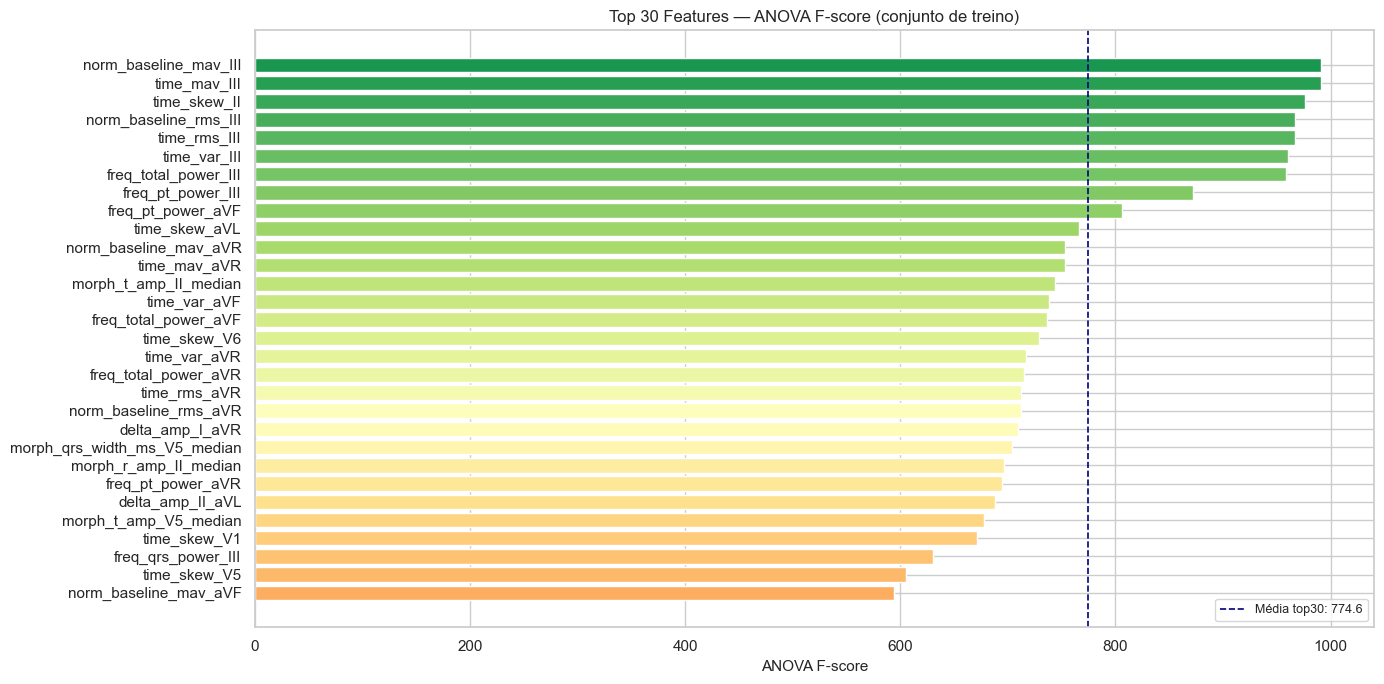

In [10]:
# Barplot — Top 30 por F-score

top30_anova = df_anova.head(30)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top30_anova['feature'][::-1], top30_anova['F_score'][::-1],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 30)))
ax.set_xlabel('ANOVA F-score', fontsize=11)
ax.set_title('Top 30 Features — ANOVA F-score (conjunto de treino)', fontsize=12)
ax.axvline(top30_anova['F_score'].mean(), color='navy', ls='--', lw=1.2,
           label=f'Média top30: {top30_anova["F_score"].mean():.1f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_anova_top30.png', dpi=150, bbox_inches='tight')
plt.show()


**Comentários sobre a subseção 3.1 — ANOVA F-score:**

* **Domínios dominantes:** o topo do ranking é majoritariamente composto por features temporais e energéticas/espectrais (`MAV`, `RMS`, `VAR`, potência espectral), indicando que diferenças globais de amplitude e distribuição de energia carregam grande parte da separabilidade entre as superclasses. Isso é coerente com o E8, onde os primeiros PCs também foram dominados por componentes de energia.

* **Participação morfológica relevante:** apesar da predominância energética, features morfológicas como amplitude da onda T, largura do QRS e amplitude da onda R aparecem entre os maiores F-scores. Isso sugere que alterações estruturais de despolarização e repolarização também possuem forte capacidade discriminativa.

* **Cauda relativamente longa:** o decaimento do F-score é gradual, não abrupto. Mesmo features fora do topo ainda apresentam valores consideráveis de F, indicando que o dataset possui muitas variáveis parcialmente discriminativas e com informação redundante — comportamento consistente com a redundância moderada observada no PCA.

* **Contraste entre topo e base do ranking:** as menores pontuações concentram features relacionadas a:

  * frequência de pico (`freq_peak_*`);
  * entropia wavelet;
  * variabilidade morfológica (`*_std`).

  Isso sugere que medidas muito locais, instáveis ou altamente dependentes de ruído possuem menor capacidade discriminativa univariada entre as superclasses.

* **Variância global ≠ poder discriminativo:** algumas features morfológicas bem posicionadas no ANOVA não apareceram entre os loadings dominantes do PCA no E8. Isso reforça que alta variância global não implica necessariamente maior relevância para classificação.

* **Significância estatística generalizada:** todas as 282 features apresentaram (p < 0.05), e praticamente todas com valores extremamente baixos. Isso indica que as superclasses do PTB-XL produzem alterações estatisticamente detectáveis em praticamente todo o espaço de atributos. Nesse cenário, o desafio principal deixa de ser detectar significância e passa a ser reduzir redundância e selecionar subconjuntos mais compactos e interpretáveis.



### 3.2 Informação Mútua

A **Informação Mútua (MI)** entre uma feature $X$ e o rótulo $Y$ mede o quanto conhecer $X$ reduz a incerteza sobre $Y$:

$$I(X; Y) = H(Y) - H(Y \mid X)$$

onde $H$ é a entropia de Shannon. $I(X; Y) = 0$ significa independência completa; valores maiores indicam maior dependência. Ao contrário do ANOVA, a MI captura relações não-lineares e não exige suposições paramétricas sobre a distribuição dos dados.

Na prática, a implementação do scikit-learn estima a MI por meio de vizinhos mais próximos (estimador de Kraskov), o que a torna computacionalmente mais custosa que o ANOVA, mas capaz de detectar dependências que o F-score deixaria passar.

Features com MI alta e F-score baixo sugerem relações não-lineares com a classe — candidatos interessantes que métodos puramente paramétricos subestimariam.


In [11]:
# Informação Mútua — estimativa por k-vizinhos (Kraskov)
# n_neighbors=5 é o padrão; discrete_features=False pois as features são contínuas

print('Calculando Informação Mútua...')
mi_vals = mutual_info_classif(X_treino, y_treino_raw,
                               discrete_features=False,
                               n_neighbors=5,
                               random_state=42)

df_mi = pd.DataFrame({
    'feature' : feature_cols,
    'MI'      : mi_vals,
}).sort_values('MI', ascending=False).reset_index(drop=True)

df_mi['rank_mi'] = df_mi.index + 1

print("Informação Mútua calculada!")

Calculando Informação Mútua...
Informação Mútua calculada!


In [15]:
# Plot de resultados significativos de Informação Mútua
 
print('Top 20 features por maior Informação Mútua:')
display(df_mi.head(20).round(5))
print()
print('Top 10 features por menor Informação Mútua:')
display(df_mi.tail(10).round(5))
print()
print(f'Features com MI > 0.10 : {(df_mi["MI"] > 0.10).sum()}')
print(f'Features com MI > 0.05 : {(df_mi["MI"] > 0.05).sum()}')
print(f'Features com MI < 0.05 : {(df_mi["MI"] < 0.05).sum()}')
print(f'Features com MI = 0    : {(df_mi["MI"] == 0).sum()}')

Top 20 features por maior Informação Mútua:


,feature,MI,rank_mi
0,morph_t_amp_V5_median,0.23263,1
1,morph_t_amp_II_median,0.19239,2
2,time_skew_II,0.15414,3
3,norm_baseline_rms_III,0.15077,4
4,time_rms_III,0.15077,5
5,time_var_III,0.14912,6
6,freq_pt_power_III,0.14875,7
7,freq_total_power_III,0.14251,8
8,delta_amp_I_aVR,0.14111,9
9,time_mav_III,0.13855,10



Top 10 features por menor Informação Mútua:


,feature,MI,rank_mi
272,wavelet_entropy_D4_V5,0.01984,273
273,time_zcr_V1,0.01908,274
274,wavelet_entropy_D4_II,0.01831,275
275,morph_qrs_width_ms_V5_std,0.01631,276
276,wavelet_qrs_ratio_V5,0.01495,277
277,time_zcr_aVR,0.01340,278
278,wavelet_entropy_A4_V5,0.01179,279
279,time_zcr_aVF,0.01126,280
280,morph_qrs_width_ms_II_std,0.00922,281
281,wavelet_entropy_A4_II,0.00566,282



Features com MI > 0.10 : 39
Features com MI > 0.05 : 203
Features com MI < 0.05 : 79
Features com MI = 0    : 0


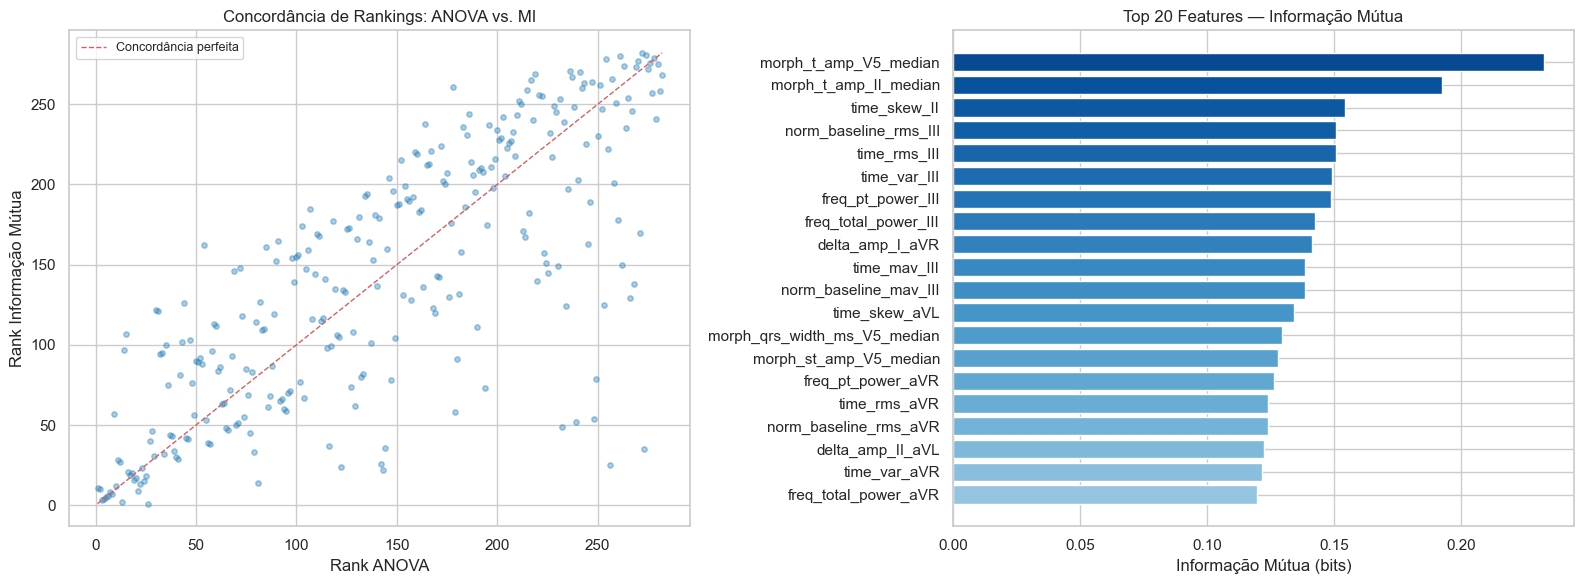

Correlação de Spearman entre rankings ANOVA e MI: ρ = 0.780  (p = 0.0000)


In [8]:
# Comparação ANOVA vs. MI — scatter plot de rankings

df_compare_fm = df_anova[['feature', 'F_score', 'rank_anova']].merge(
    df_mi[['feature', 'MI', 'rank_mi']], on='feature'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter rank_anova x rank_mi
axes[0].scatter(df_compare_fm['rank_anova'], df_compare_fm['rank_mi'],
                alpha=0.4, s=15, color='#2980b9')
axes[0].plot([1, len(feature_cols)], [1, len(feature_cols)],
             'r--', lw=1, label='Concordância perfeita')
axes[0].set_xlabel('Rank ANOVA')
axes[0].set_ylabel('Rank Informação Mútua')
axes[0].set_title('Concordância de Rankings: ANOVA vs. MI')
axes[0].legend(fontsize=9)

# Top 20 MI — barplot
top20_mi = df_mi.head(20)
axes[1].barh(top20_mi['feature'][::-1], top20_mi['MI'][::-1],
             color=plt.cm.Blues(np.linspace(0.4, 0.9, 20)))
axes[1].set_xlabel('Informação Mútua (bits)')
axes[1].set_title('Top 20 Features — Informação Mútua')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_mi_comparacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlação de Spearman entre os dois rankings
from scipy.stats import spearmanr
rho, p_rho = spearmanr(df_compare_fm['rank_anova'], df_compare_fm['rank_mi'])
print(f'Correlação de Spearman entre rankings ANOVA e MI: ρ = {rho:.3f}  (p = {p_rho:.4f})')


**Comentários sobre a subseção 3.2 — Informação Mútua:**

* **Consistência entre ANOVA e MI:** os rankings apresentaram correlação de Spearman relativamente alta ((\rho = 0.780)), indicando forte concordância entre os dois critérios (como pôde ser atestado com a predominância de features temporais, energéticas e morfológicas no topo). Isso sugere que grande parte das features discriminativas do PTB-XL já é capturada por diferenças relativamente lineares e monotônicas entre as classes.

* **Maior destaque morfológico na MI:** apesar da concordância global, a MI elevou ainda mais features ligadas à repolarização e morfologia ventricular, como:

  * `morph_t_amp_V5_median`
  * `morph_t_amp_II_median`
  * `morph_st_amp_V5_median`

  Isso sugere relações parcialmente não-lineares entre alterações morfológicas e os rótulos clínicos.

* **Features potencialmente subestimadas pelo ANOVA:** algumas métricas morfológicas aparecem relativamente mais fortes na MI do que no F-score, indicando dependências que não se manifestam apenas como diferença de média entre classes. Essas features são particularmente relevantes porque poderiam passar despercebidas em filtros puramente paramétricos.

* **Baixa relevância de métricas não-lineares clássicas:** entropias wavelet e métricas derivadas de cruzamento por zero (`ZCR`) permaneceram entre os menores rankings também na MI. Portanto, neste conjunto de features, os descritores não-lineares clássicos não mostraram ganho expressivo de discriminatividade mesmo sob um método sensível a relações complexas.

* **Distribuição mais seletiva dos scores:** diferentemente do ANOVA — onde praticamente todas as features foram altamente significativas — a MI apresentou separação mais clara entre variáveis fortes e fracas:

  * 39 features com MI > 0.10;
  * 79 features com MI < 0.05.

  Isso sugere que significância estatística não implica necessariamente alto conteúdo informacional para classificação.

* **Ausência de independência total:** nenhuma feature apresentou MI = 0, indicando que todas preservam algum grau de dependência com as classes. Isso reforça a elevada densidade informacional do espaço de atributos e sugere que a seleção posterior deverá priorizar redução de redundância, não apenas eliminação de features irrelevantes.

### 3.3 ReliefF

O **Relief** (Kononenko, 1994) é um algoritmo de seleção baseado na ideia de que uma feature boa deve apresentar valores similares entre instâncias da mesma classe (*near-hits*) e valores diferentes entre instâncias de classes distintas (*near-misses*).

Para cada instância amostrada, o algoritmo identifica os $k$ vizinhos mais próximos de mesma classe e das demais classes, e atualiza o score de cada feature de acordo com a diferença de valores observada. Features cujos valores divergem muito entre vizinhos de classes distintas recebem scores altos; features que divergem dentro da mesma classe são penalizadas.

A versão **ReliefF** (com F) é uma extensão do Relief original para suporte a múltiplas classes — essencial neste contexto, onde temos 5 superclasses diagnósticas.

Diferentemente do ANOVA e da MI, o ReliefF captura **interações locais** entre features, tornando-o especialmente sensível a padrões discriminativos que se manifestam apenas em certas regiões do espaço de features.


In [19]:
# ReliefF — cálculo dos scores

if RELIEFF_OK:

    # ReliefF possui custo computacional elevado (~O(n²))
    # Portanto, utilizamos uma amostra aleatória do treino
    N_SAMPLE_RF = min(5000, X_treino.shape[0])

    idx_sample = np.random.choice(
        X_treino.shape[0],
        N_SAMPLE_RF,
        replace=False
    )

    X_rf_sample = X_treino[idx_sample]
    y_rf_sample = y_treino_enc[idx_sample]

    print(f'Rodando ReliefF em {N_SAMPLE_RF} instâncias (k=10)...')

    relieff = ReliefF(
        n_features_to_select=len(feature_cols),
        n_neighbors=10,
        n_jobs=-1
    )

    relieff.fit(X_rf_sample, y_rf_sample)

    df_relieff = (
        pd.DataFrame({
            'feature': feature_cols,
            'relieff_score': relieff.feature_importances_
        })
        .sort_values('relieff_score', ascending=False)
        .reset_index(drop=True)
    )

    df_relieff['rank_relieff'] = df_relieff.index + 1
    print("ReliefF calculado!")

else:
    print('ReliefF não disponível. Pulando subseção 3.3.')

    df_relieff = pd.DataFrame({
        'feature': feature_cols,
        'relieff_score': np.nan,
        'rank_relieff': range(1, len(feature_cols) + 1)
    })

Rodando ReliefF em 5000 instâncias (k=10)...
ReliefF calculado!


In [24]:
# ReliefF — visualização e estatísticas

if RELIEFF_OK:

    print('Top 20 features por ReliefF:')
    display(df_relieff.head(20).round(5))

    # Features penalizadas pelo algoritmo
    n_neg = (df_relieff['relieff_score'] < 0).sum()

    print(
        f'\nFeatures com score negativo '
        f'(penalizadas): {n_neg} de {len(feature_cols)}'
    )

Top 20 features por ReliefF:


,feature,relieff_score,rank_relieff
0,morph_r_amp_II_median,0.04487,1
1,delta_amp_II_aVL,0.04147,2
2,time_p2p_aVR,0.03660,3
3,time_skew_III,0.03593,4
4,morph_r_amp_V5_median,0.03558,5
5,morph_qrs_width_ms_II_median,0.03456,6
6,morph_t_amp_II_median,0.03406,7
7,morph_t_amp_V5_median,0.03319,8
8,time_skew_aVF,0.03113,9
9,time_skew_aVR,0.03074,10



Features com score negativo (penalizadas): 0 de 282


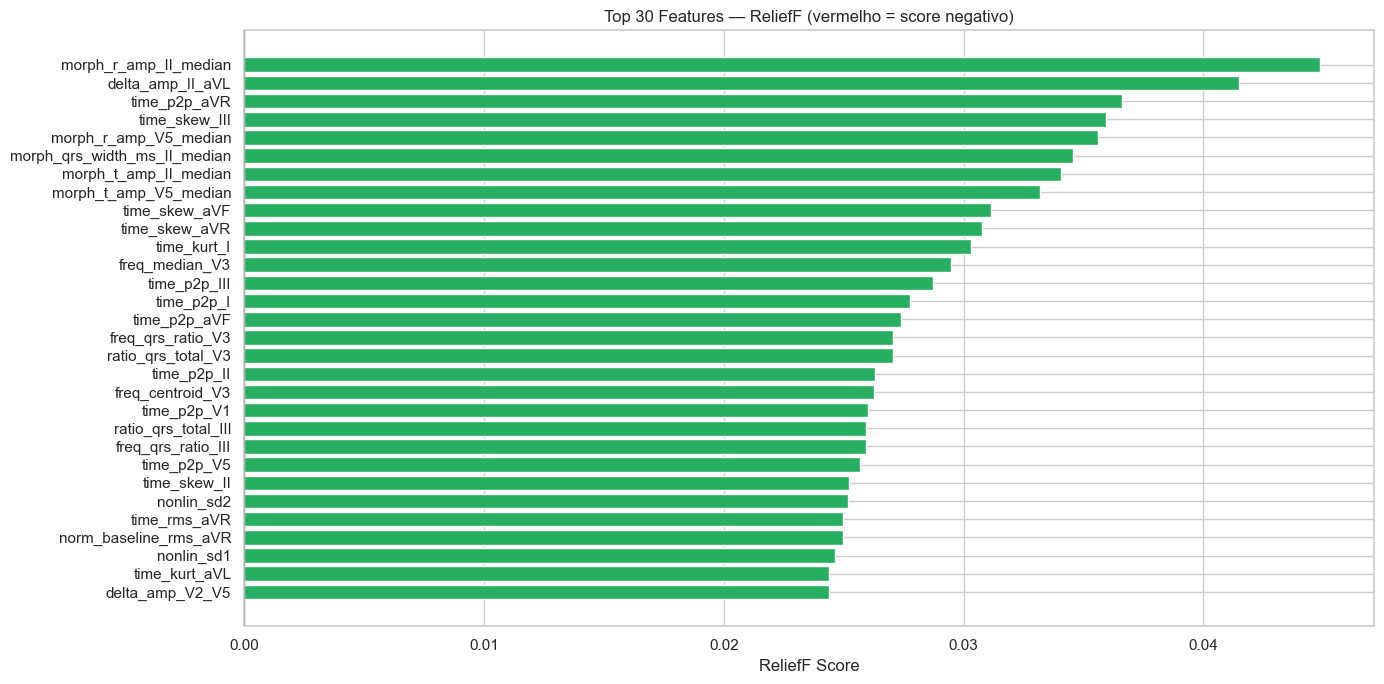

In [21]:
# Barplot ReliefF — Top 30

if RELIEFF_OK:
    top30_rf = df_relieff.head(30)
    fig, ax  = plt.subplots(figsize=(14, 7))
    cores    = ['#c0392b' if s < 0 else '#27ae60' for s in top30_rf['relieff_score'][::-1]]
    ax.barh(top30_rf['feature'][::-1], top30_rf['relieff_score'][::-1], color=cores)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('ReliefF Score')
    ax.set_title('Top 30 Features — ReliefF (vermelho = score negativo)', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'sel_relieff_top30.png', dpi=150, bbox_inches='tight')
    plt.show()


**Comentários sobre a subseção 3.3 — ReliefF:**

* **Maior diversidade de domínios:** diferentemente do ANOVA e da MI — dominados principalmente por métricas energéticas — o ReliefF trouxe maior diversidade de features relevantes, incluindo:

  * amplitudes morfológicas;
  * largura do QRS;
  * estatísticas de forma (`skewness`, `kurtosis`);
  * razões espectrais;
  * métricas não-lineares (`SD1`, `SD2`).

  Isso sugere que o algoritmo foi mais sensível a padrões discriminativos locais e interações entre atributos.

* **Features subestimadas pelos outros filtros:** algumas variáveis aparecem muito melhor posicionadas no ReliefF do que no ANOVA/MI, como:

  * `time_p2p_*`
  * `freq_centroid_V3`
  * `nonlin_sd1`
  * `nonlin_sd2`

  Esse comportamento indica relações potencialmente não-lineares ou dependentes da geometria local do espaço de features, que filtros univariados tendem a subestimar.

* **Maior presença de métricas não-lineares:** ao contrário do ANOVA e da MI, o ReliefF elevou métricas não-lineares (`SD1`, `SD2`) para posições relativamente altas. Fisiologicamente, isso é coerente: alterações autonômicas e dinâmicas de variabilidade cardíaca podem não produzir diferenças globais de média, mas ainda assim modificar a estrutura local das distribuições.

* **Consistência parcial com os outros métodos:** algumas features permaneceram fortes em todos os filtros, especialmente:

  * `morph_t_amp_II_median`
  * `morph_t_amp_V5_median`
  * `time_skew_*`
  * `time_rms_aVR`

  Isso sugere que certos padrões discriminativos são robustos independentemente do critério estatístico utilizado.

* **Ausência de scores negativos:** nenhuma feature recebeu score negativo. Isso indica que, mesmo em análise baseada em vizinhança local, nenhuma variável mostrou comportamento consistentemente prejudicial à separação entre classes.

* **Impacto da amostragem:** o ReliefF foi executado sobre uma subamostra do conjunto de treino devido ao alto custo computacional do algoritmo. Considerando o grande volume do PTB-XL, uma amostra de milhares de instâncias ainda tende a preservar adequadamente a estrutura estatística global, embora pequenas variações no ranking possam ocorrer entre diferentes execuções aleatórias.



### 3.4 Síntese dos Filter Methods — Ranking Consolidado

Para consolidar os resultados dos três filtros, construímos um **ranking agregado por média de posição** (Borda Count adaptado). Esse método é simples, robusto a outliers de ranking e não exige que as escalas dos scores sejam comparáveis entre os métodos.

O ranking final por filtros serve como referência exploratória e como base de comparação com os métodos wrapper e embedded nas seções seguintes.


In [23]:
# Consolidação dos rankings de filter methods

df_filter_final = (df_anova[['feature', 'F_score', 'rank_anova']]
                   .merge(df_mi[['feature', 'MI', 'rank_mi']], on='feature')
                   .merge(df_relieff[['feature', 'relieff_score', 'rank_relieff']], on='feature'))

# Rank agregado: média dos três rankings (menor = melhor)
df_filter_final['rank_filter_avg'] = (
    df_filter_final[['rank_anova', 'rank_mi', 'rank_relieff']].mean(axis=1)
)
df_filter_final = df_filter_final.sort_values('rank_filter_avg').reset_index(drop=True)
df_filter_final['rank_filter'] = df_filter_final.index + 1

print('Top 30 melhores features consolidadas pelos Filter Methods (Borda Count):')
display(df_filter_final[['feature', 'F_score', 'MI', 'relieff_score',
                          'rank_anova', 'rank_mi', 'rank_relieff',
                          'rank_filter']].head(30).round(4))

print('Top 30 piores features consolidadas pelos Filter Methods (Borda Count):')
display(df_filter_final[['feature', 'F_score', 'MI', 'relieff_score',
                          'rank_anova', 'rank_mi', 'rank_relieff',
                          'rank_filter']].tail(30).round(4))


Top 30 melhores features consolidadas pelos Filter Methods (Borda Count):


,feature,F_score,MI,relieff_score,rank_anova,rank_mi,rank_relieff,rank_filter
0,morph_t_amp_II_median,744.0937,0.1924,0.0341,13,2,7,1
1,time_skew_II,976.5976,0.1541,0.0252,3,3,24,2
2,morph_t_amp_V5_median,678.1233,0.2326,0.0332,26,1,8,3
3,norm_baseline_rms_III,967.2209,0.1508,0.0237,4,4,37,4
4,delta_amp_II_aVL,687.8677,0.1222,0.0415,25,18,2,5
5,morph_r_amp_II_median,696.8358,0.1136,0.0449,23,23,1,6
6,time_rms_III,967.2209,0.1508,0.0237,5,5,38,7
7,time_rms_aVR,712.0542,0.1237,0.0250,19,16,26,8
8,norm_baseline_rms_aVR,712.0542,0.1237,0.0250,20,17,27,9
9,time_skew_aVL,766.5902,0.1341,0.0221,10,12,43,10


Top 30 piores features consolidadas pelos Filter Methods (Borda Count):


,feature,F_score,MI,relieff_score,rank_anova,rank_mi,rank_relieff,rank_filter
252,morph_qrs_width_ms_II_std,31.6789,0.0092,0.0162,274,281,148,253
253,freq_qrs_power_V2,140.1312,0.0258,0.0107,217,265,222,254
254,wavelet_rel_energy_D3_V5,82.2667,0.0401,0.0103,250,230,225,255
255,time_kurt_V2,126.7388,0.0325,0.0099,228,249,229,256
256,ratio_qrs_pt_aVF,101.2863,0.0503,0.0055,240,203,266,257
257,morph_st_amp_II_std,213.1653,0.0285,0.0048,178,261,270,258
258,hrv_rmssd,95.8941,0.0428,0.0080,244,225,246,259
259,morph_qrs_asym_V5_std,42.3743,0.0610,0.0031,271,170,276,260
260,time_zcr_V2,107.0664,0.0203,0.0115,236,271,216,261
261,wavelet_rel_energy_D4_V5,76.9311,0.0329,0.0105,252,247,224,262


### Concordância entre os filtros

Para avaliar a consistência entre os métodos de seleção por filtro, foi construído um heatmap com os rankings normalizados das 50 features mais relevantes no ranking agregado. Cada coluna representa um método (`ANOVA`, `MI` e `ReliefF`), enquanto cada linha corresponde a uma feature.

Os rankings foram normalizados para o intervalo \([0,1]\), onde:

- valores próximos de `0` indicam features muito bem posicionadas;
- valores próximos de `1` indicam posições relativamente piores dentro do subconjunto analisado.

A visualização permite identificar:

- features consistentemente bem ranqueadas em todos os métodos;
- discordâncias entre filtros;
- possíveis padrões não-lineares capturados apenas pelo ReliefF ou pela MI;
- redundância entre métricas estatísticas tradicionais.

Além disso, blocos verticais de coloração semelhante sugerem concordância estrutural entre os filtros, enquanto discrepâncias localizadas indicam features cujo comportamento discriminativo depende do critério estatístico utilizado.

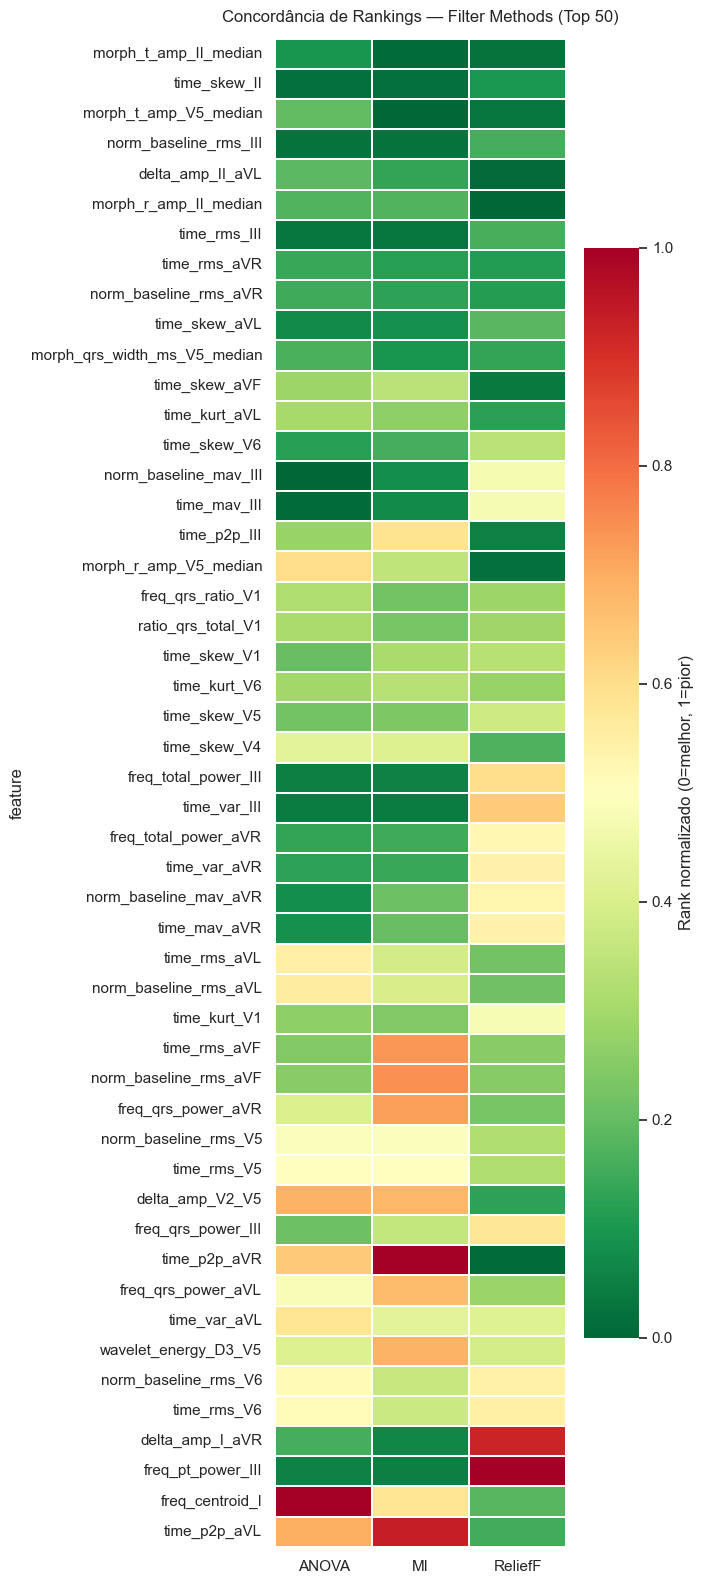

In [25]:
# Heatmap de concordância entre rankings dos filtros (Top 50 features)

top50_features = df_filter_final.head(50)['feature'].tolist()
df_hm = df_filter_final.set_index('feature').loc[top50_features,
        ['rank_anova', 'rank_mi', 'rank_relieff']]

# Normaliza rankings para [0, 1] — facilita leitura visual
df_hm_norm = df_hm.apply(lambda c: (c - c.min()) / (c.max() - c.min()))

fig, ax = plt.subplots(figsize=(7, 16))
sns.heatmap(df_hm_norm, cmap='RdYlGn_r', ax=ax,
            yticklabels=top50_features,
            xticklabels=['ANOVA', 'MI', 'ReliefF'],
            cbar_kws={'label': 'Rank normalizado (0=melhor, 1=pior)'},
            linewidths=0.2)
ax.set_title('Concordância de Rankings — Filter Methods (Top 50)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_filter_concordancia_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


* **Consistência entre os filtros:** o ranking agregado mostrou forte predominância de features que já apareciam bem posicionadas individualmente nos três métodos, especialmente métricas morfológicas da onda T, largura/amplitude do QRS e estatísticas temporais de assimetria (`skewness`). Isso sugere que certos padrões discriminativos são estruturalmente robustos independentemente do critério estatístico adotado.

* **Predomínio morfológico no ranking consolidado:** as primeiras posições ficaram concentradas em features relacionadas à morfologia ventricular e repolarização:

  * `morph_t_amp_II_median`
  * `morph_t_amp_V5_median`
  * `morph_r_amp_II_median`
  * `morph_qrs_width_ms_V5_median`

  Fisiologicamente, isso é coerente com alterações elétricas produzidas por infarto, hipertrofia e distúrbios de condução, que modificam diretamente amplitudes e durações das ondas cardíacas.

* **Features robustas vs. especializadas:** algumas variáveis apresentaram bom desempenho simultâneo nos três filtros, enquanto outras foram impulsionadas principalmente por um único método. Por exemplo:

  * `morph_t_amp_II_median` permaneceu consistentemente forte em ANOVA, MI e ReliefF;
  * `time_p2p_aVR` teve posição extremamente alta no ReliefF, mas desempenho relativamente inferior nos demais filtros.

  Isso sugere que certas features capturam padrões globais estáveis, enquanto outras dependem mais de relações locais e não-lineares.

* **Discordâncias entre filtros:** o heatmap evidencia blocos de concordância parcial entre ANOVA e MI, mas divergências maiores envolvendo o ReliefF. Features energéticas como:

  * `freq_total_power_III`
  * `time_var_III`
  * `freq_pt_power_III`

  foram extremamente fortes nos filtros univariados, mas perderam relevância relativa no ReliefF. Isso sugere que parte dessas métricas possui alta separabilidade marginal, porém menor contribuição local quando consideradas em conjunto com outras variáveis.

* **Features persistentemente fracas:** o final do ranking foi dominado por:

  * entropias wavelet;
  * `ZCR`;
  * variabilidade (`*_std`) de métricas morfológicas;
  * frequências de pico.

  Essas features permaneceram mal posicionadas de forma relativamente consistente nos três filtros, indicando baixo conteúdo discriminativo isolado e possível sensibilidade a ruído/intervariabilidade fisiológica.

* **Ausência de features claramente inúteis:** mesmo as últimas posições ainda apresentaram scores positivos em todos os métodos. Isso reforça a ideia já observada anteriormente: o espaço de atributos do PTB-XL é densamente informativo, e o principal problema não é ausência de sinal discriminativo, mas excesso de redundância entre features parcialmente correlacionadas.


---

## 4. Wrapper Methods

### Fundamentação

Os wrapper methods avaliam subconjuntos de features **treinando e validando um estimador** sobre cada subconjunto candidato. Por serem acoplados ao classificador, capturam interações entre features e fornecem uma estimativa de desempenho mais realista do que os filtros — mas com custo computacional significativamente maior.

O estimador utilizado aqui é a **Regressão Logística** com regularização L2 leve (`C=1`), escolhida por ser rápida, estável e interpretável. Classificadores mais complexos (como SVM ou Random Forest) tornariam o processo computacionalmente proibitivo sem hardware dedicado.

A validação é feita por **cross-validation estratificada de 5 folds** sobre o conjunto de treino. O critério de parada nos métodos sequenciais é o número de features a selecionar, fixado em um conjunto de valores a analisar.

> **Nota sobre custo computacional:** SFS e SBE são processos iterativos que avaliam múltiplos subconjuntos de features. Para um dataset com centenas de features, o processo pode ser demorado — o parâmetro `n_features_to_select` deve ser definido com cuidado e, na prática, aplicado sobre um subconjunto pré-filtrado de features candidatas (as top-K dos filter methods).


### 4.1 Sequential Forward Selection (SFS)

O **SFS** começa com um conjunto vazio de features e, a cada iteração, adiciona a feature que mais aumenta o desempenho do estimador (dado o subconjunto já selecionado). O processo continua até atingir o número alvo de features.

O SFS é **guloso** — não reverte decisões anteriores. Isso pode levar a subconjuntos subótimos quando duas features individualmente fracas são coletivamente fortes (a primeira pode não ser selecionada antes que a segunda apareça). Ainda assim, é o método mais comum por seu equilíbrio entre custo e qualidade.

Para tornar o processo viável, aplicamos o SFS sobre as **top-50 features pelos filter methods**, reduzindo o espaço de busca sem comprometer a qualidade do resultado.


In [46]:
# SFS — aplicado sobre pré-seleção dos filter methods

TOP_K_FILTER = 50   # features pré-filtradas como candidatas ao wrapper
N_SELECT_SFS = 20   # número final de features a selecionar

# Verifica se SFS já foi calculado em sessão anterior
path_sfs_features = WRAPPERS_DIR / 'wrapper_sfs_features.parquet'
path_sfs_mask     = WRAPPERS_DIR / 'wrapper_sfs_mask.npy'

if path_sfs_features.exists() and path_sfs_mask.exists():

    print('Outputs do SFS já encontrados. Carregando resultados salvos...')
    print()

    df_sfs = pd.read_parquet(path_sfs_features)
    mask_sfs = np.load(path_sfs_mask)

    features_sfs = df_sfs['feature'].tolist()

else:

    top_k_features  = df_filter_final.head(TOP_K_FILTER)['feature'].tolist()
    idx_top_k       = [feature_cols.index(f) for f in top_k_features]

    X_treino_topk   = X_treino[:, idx_top_k]

    estimador_sfs = LogisticRegression(C=1, max_iter=500, random_state=42,
                                        solver='saga')

    cv_sfs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f'Rodando SFS: {TOP_K_FILTER} candidatas --> {N_SELECT_SFS} selecionadas...')
    print(f'Estimador  : LogisticRegression(C=1, multinomial)')
    print(f'CV         : StratifiedKFold(n_splits=5)')
    print()

    sfs = SequentialFeatureSelector(
        estimador_sfs,
        n_features_to_select=N_SELECT_SFS,
        direction='forward',
        scoring='accuracy',
        cv=cv_sfs,
        n_jobs=-1
    )

    # Evita incompatibilidade pandas/pyarrow com sklearn + joblib
    y_sfs = np.asarray(y_treino_raw)
    sfs.fit(X_treino_topk, y_sfs)

    # Extrai features selecionadas
    mask_sfs      = sfs.get_support()
    features_sfs  = [top_k_features[i] for i in range(TOP_K_FILTER) if mask_sfs[i]]

print(f'Features selecionadas pelo SFS ({N_SELECT_SFS}):')
for i, f in enumerate(features_sfs, 1):
    print(f'  {i:2d}. {f}')

Outputs do SFS já encontrados. Carregando resultados salvos...

Features selecionadas pelo SFS (20):
   1. morph_t_amp_II_median
   2. time_skew_II
   3. morph_t_amp_V5_median
   4. morph_r_amp_II_median
   5. morph_qrs_width_ms_V5_median
   6. time_skew_V6
   7. norm_baseline_mav_III
   8. time_p2p_III
   9. morph_r_amp_V5_median
  10. time_skew_V1
  11. time_skew_V4
  12. freq_total_power_III
  13. time_rms_aVL
  14. delta_amp_V2_V5
  15. freq_qrs_power_III
  16. freq_qrs_power_aVL
  17. wavelet_energy_D3_V5
  18. norm_baseline_rms_V6
  19. freq_pt_power_III
  20. freq_centroid_I


**Comentários sobre a subseção 4.1 — SFS:**

* **Seleção multimodal de features:** o SFS não ficou concentrado em um único domínio. O subconjunto final combinou:

  * métricas morfológicas (`morph_*`);
  * estatísticas temporais (`skew`, `p2p`, `RMS`);
  * métricas espectrais (`power`, `centroid`);
  * componentes wavelet.

  Isso sugere que a discriminação entre as superclasses do PTB-XL depende de mecanismos fisiológicos complementares, envolvendo simultaneamente morfologia, energia e distribuição espectral do ECG.

* **Predomínio morfológico nas primeiras escolhas:** as primeiras features adicionadas pelo SFS foram majoritariamente morfológicas e temporais associadas à repolarização e assimetria do sinal:

  * `morph_t_amp_II_median`
  * `morph_t_amp_V5_median`
  * `morph_r_amp_II_median`
  * `time_skew_*`

  Isso é coerente com os resultados anteriores dos filter methods, reforçando que alterações de amplitude e forma das ondas carregam forte conteúdo diagnóstico no PTB-XL.

* **Features resgatadas pelo contexto multivariado:** algumas features selecionadas pelo SFS não estavam entre as melhores posições individuais dos filtros, como:

  * `wavelet_energy_D3_V5`
  * `freq_centroid_I`
  * `freq_qrs_power_aVL`
  * `delta_amp_V2_V5`

  Esse comportamento é esperado em wrapper methods: uma feature pode ter relevância moderada isoladamente, mas fornecer informação complementar importante quando combinada com outras variáveis já selecionadas.

* **Redução de redundância:** o SFS evitou selecionar simultaneamente muitas features altamente correlacionadas que apareciam no topo dos filter methods. Por exemplo, embora várias métricas de energia em `III` e `aVR` fossem muito fortes individualmente, apenas parte delas permaneceu no subconjunto final. Isso sugere que o wrapper já atua implicitamente como mecanismo de controle de redundância.

* **Ausência de features claramente não-lineares:** métricas mais complexas de dinâmica não-linear (`entropy`, `HRV`, `DFA`) praticamente não apareceram entre as selecionadas. Isso indica que, ao menos sob um classificador linear como a regressão logística, o ganho incremental dessas features foi pequeno frente às métricas morfológicas e energéticas tradicionais.

* **Tamanho do subconjunto:** selecionar 20 features para um espaço original de 282 representa uma redução agressiva (~93%), mas ainda preservando diversidade fisiológica. O próximo passo natural é avaliar a curva de desempenho do SFS em função de `N_SELECT_SFS`, verificando se a acurácia já saturou próximo de 20 variáveis ou se ainda há ganho relevante com subconjuntos maiores.


> Optou-se por não realizar uma varredura extensiva sobre diferentes valores de `n_features_to_select`, dado o alto custo computacional do SFS e o fato de que o objetivo desta etapa é comparativo, não de otimização fina. O valor de 20 features foi considerado um compromisso adequado entre interpretabilidade, diversidade fisiológica e viabilidade computacional.

In [44]:
# Persistência dos resultados do SFS (haja visto que o método é demorado demais)

# Tempo de execução (preencher manualmente, se desejar)
tempo_sfs_min = 12.04

# DataFrame consolidado do SFS
df_sfs = pd.DataFrame({
    'feature'       : features_sfs,
    'selected_sfs'  : True,
    'ordem_sfs'     : range(1, len(features_sfs) + 1)
})

# Metadados resumidos
df_sfs_meta = pd.DataFrame({
    'TOP_K_FILTER'     : [TOP_K_FILTER],
    'N_SELECT_SFS'     : [N_SELECT_SFS],
    'estimador'        : ['LogisticRegression(solver=saga, C=1)'],
    'cv'               : ['StratifiedKFold(n_splits=5)'],
    'tempo_exec_min'   : [tempo_sfs_min]
})

# ------------------------------------------------------------
# Salvamento
# ------------------------------------------------------------

df_sfs.to_parquet(
    WRAPPERS_DIR / 'wrapper_sfs_features.parquet',
    index=False
)

df_sfs_meta.to_parquet(
    WRAPPERS_DIR / 'wrapper_sfs_metadata.parquet',
    index=False
)

np.save(
    WRAPPERS_DIR / 'wrapper_sfs_mask.npy',
    mask_sfs
)

print('Resultados do SFS salvos com sucesso:')
print(' - wrapper_sfs_features.parquet')
print(' - wrapper_sfs_metadata.parquet')
print(' - wrapper_sfs_mask.npy')

Resultados do SFS salvos com sucesso:
 - wrapper_sfs_features.parquet
 - wrapper_sfs_metadata.parquet
 - wrapper_sfs_mask.npy


### 4.2 Sequential Backward Elimination (SBE)

O **SBE** parte do conjunto completo de features pré-filtradas e, a cada iteração, remove a feature cuja ausência **menos reduz** o desempenho do estimador. O processo continua até atingir o número alvo de features.

O SBE tende a ser mais conservador que o SFS — começa com toda a informação disponível e retira o que é menos necessário, o que pode preservar melhor interações entre features. Por outro lado, é computacionalmente ainda mais custoso em espaços de alta dimensão, pois começa avaliando subconjuntos maiores.

A comparação entre SFS e SBE revela se a seleção de features é sensível à direção da busca — quando ambos concordam, o subconjunto selecionado é mais confiável.


In [49]:
# SBE — mesma configuração do SFS, direção invertida

N_SELECT_SBE = 20

# ------------------------------------------------------------
# Verifica se outputs já existem
# ------------------------------------------------------------

path_sbe_features = WRAPPERS_DIR / 'wrapper_sbe_features.parquet'
path_sbe_mask     = WRAPPERS_DIR / 'wrapper_sbe_mask.npy'

if path_sbe_features.exists() and path_sbe_mask.exists():

    print('Outputs do SBE já encontrados. Carregando resultados salvos...')
    print()

    df_sbe = pd.read_parquet(path_sbe_features)
    mask_sbe = np.load(path_sbe_mask)

    features_sbe = df_sbe['feature'].tolist()

else:

    print(f'Rodando SBE: {TOP_K_FILTER} candidatas --> {N_SELECT_SBE} selecionadas...')
    print()

    sbe = SequentialFeatureSelector(
        estimador_sfs,
        n_features_to_select=N_SELECT_SBE,
        direction='backward',
        scoring='accuracy',
        cv=cv_sfs,
        n_jobs=-1
    )

    sbe.fit(X_treino_topk, y_sfs)

    mask_sbe      = sbe.get_support()
    features_sbe  = [top_k_features[i] for i in range(TOP_K_FILTER) if mask_sbe[i]]

print(f'Features selecionadas pelo SBE ({N_SELECT_SBE}):')
for i, f in enumerate(features_sbe, 1):
    print(f'  {i:2d}. {f}')

Outputs do SBE já encontrados. Carregando resultados salvos...

Features selecionadas pelo SBE (20):
   1. morph_t_amp_II_median
   2. time_skew_II
   3. morph_t_amp_V5_median
   4. delta_amp_II_aVL
   5. time_skew_aVL
   6. morph_qrs_width_ms_V5_median
   7. time_kurt_aVL
   8. time_mav_III
   9. time_p2p_III
  10. morph_r_amp_V5_median
  11. ratio_qrs_total_V1
  12. time_skew_V1
  13. norm_baseline_rms_aVL
  14. time_kurt_V1
  15. freq_qrs_power_aVR
  16. delta_amp_V2_V5
  17. freq_qrs_power_III
  18. wavelet_energy_D3_V5
  19. time_rms_V6
  20. freq_centroid_I


In [64]:
# Persistência dos resultados do SBE

# Tempo de execução (preencher manualmente, se desejar)
tempo_sbe_min = 204.54

# DataFrame consolidado do SBE
df_sbe = pd.DataFrame({
    'feature'       : features_sbe,
    'selected_sbe'  : True,
    'ordem_sbe'     : range(1, len(features_sbe) + 1)
})

# Metadados resumidos
df_sbe_meta = pd.DataFrame({
    'TOP_K_FILTER'     : [TOP_K_FILTER],
    'N_SELECT_SBE'     : [N_SELECT_SBE],
    'estimador'        : ['LogisticRegression(solver=saga, C=1)'],
    'cv'               : ['StratifiedKFold(n_splits=5)'],
    'tempo_exec_min'   : [tempo_sbe_min]
})

# ------------------------------------------------------------
# Salvamento
# ------------------------------------------------------------

df_sbe.to_parquet(
    WRAPPERS_DIR / 'wrapper_sbe_features.parquet',
    index=False
)

df_sbe_meta.to_parquet(
    WRAPPERS_DIR / 'wrapper_sbe_metadata.parquet',
    index=False
)

np.save(
    WRAPPERS_DIR / 'wrapper_sbe_mask.npy',
    mask_sbe
)

print('Resultados do SBE salvos com sucesso:')
print(' - wrappers/wrapper_sbe_features.parquet')
print(' - wrappers/wrapper_sbe_metadata.parquet')
print(' - wrappers/wrapper_sbe_mask.npy')

Resultados do SBE salvos com sucesso:
 - wrappers/wrapper_sbe_features.parquet
 - wrappers/wrapper_sbe_metadata.parquet
 - wrappers/wrapper_sbe_mask.npy


In [50]:
# Comparação SFS vs. SBE

features_sfs_set = set(features_sfs)
features_sbe_set = set(features_sbe)

intersecao    = features_sfs_set & features_sbe_set
somente_sfs   = features_sfs_set - features_sbe_set
somente_sbe   = features_sbe_set - features_sfs_set

print(f'Interseção SFS ∩ SBE  : {len(intersecao)} features')
print(f'Apenas no SFS         : {len(somente_sfs)} features')
print(f'Apenas no SBE         : {len(somente_sbe)} features')
print()
print('Features presentes em ambos (núcleo robusto):')
for f in sorted(intersecao):
    print(f'  • {f}')
print()
print('Apenas no SFS:')
for f in sorted(somente_sfs): print(f'  • {f}')
print('Apenas no SBE:')
for f in sorted(somente_sbe): print(f'  • {f}')


Interseção SFS ∩ SBE  : 11 features
Apenas no SFS         : 9 features
Apenas no SBE         : 9 features

Features presentes em ambos (núcleo robusto):
  • delta_amp_V2_V5
  • freq_centroid_I
  • freq_qrs_power_III
  • morph_qrs_width_ms_V5_median
  • morph_r_amp_V5_median
  • morph_t_amp_II_median
  • morph_t_amp_V5_median
  • time_p2p_III
  • time_skew_II
  • time_skew_V1
  • wavelet_energy_D3_V5

Apenas no SFS:
  • freq_pt_power_III
  • freq_qrs_power_aVL
  • freq_total_power_III
  • morph_r_amp_II_median
  • norm_baseline_mav_III
  • norm_baseline_rms_V6
  • time_rms_aVL
  • time_skew_V4
  • time_skew_V6
Apenas no SBE:
  • delta_amp_II_aVL
  • freq_qrs_power_aVR
  • norm_baseline_rms_aVL
  • ratio_qrs_total_V1
  • time_kurt_V1
  • time_kurt_aVL
  • time_mav_III
  • time_rms_V6
  • time_skew_aVL


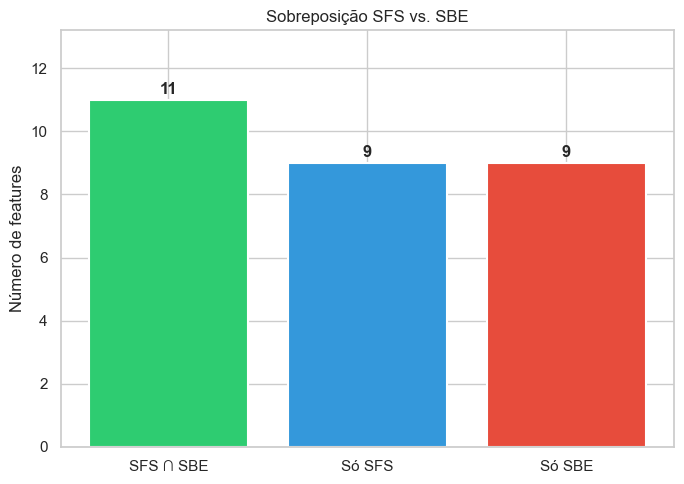

In [51]:
# Diagrama de Venn simplificado — sobreposição SFS/SBE

fig, ax = plt.subplots(figsize=(7, 5))

# Representação textual com cores
categorias = {
    'SFS ∩ SBE'  : (len(intersecao), '#2ecc71'),
    'Só SFS'     : (len(somente_sfs), '#3498db'),
    'Só SBE'     : (len(somente_sbe), '#e74c3c'),
}
bars  = list(categorias.keys())
vals  = [v[0] for v in categorias.values()]
cores = [v[1] for v in categorias.values()]

ax.bar(bars, vals, color=cores, edgecolor='white', linewidth=1.5)
for bar_x, val in zip(bars, vals):
    ax.text(bar_x, val + 0.1, str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de features')
ax.set_title('Sobreposição SFS vs. SBE')
ax.set_ylim(0, max(vals) * 1.2)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_wrapper_sobreposicao.png', dpi=150, bbox_inches='tight')
plt.show()


**Comentários sobre a subseção 4.2 — SBE e Comparação com SFS:**

A interseção entre SFS e SBE foi relativamente alta: 11 das 20 features selecionadas apareceram em ambos os métodos. Isso sugere a existência de um núcleo robusto de features discriminativas, menos sensível à direção da busca sequencial. Features presentes simultaneamente nos dois wrappers tendem a ser mais confiáveis, pois demonstraram relevância tanto quando adicionadas progressivamente quanto quando preservadas durante a eliminação regressiva.

O núcleo comum apresentou boa diversidade de domínios, incluindo features morfológicas (`morph_t_amp_*`, `morph_r_amp_*`, `morph_qrs_width_*`), temporais (`time_skew_*`, `time_p2p_*`), espectrais (`freq_*`) e até wavelets (`wavelet_energy_D3_V5`). Essa distribuição sugere que a discriminação entre classes depende de múltiplos aspectos do ECG, e não apenas de um único domínio de análise.

As features exclusivas do SFS tenderam a incluir métricas mais fortes individualmente nos filter methods, como potência espectral total e métricas RMS/MAV. Já o SBE preservou algumas features mais contextuais, como razões espectrais (`ratio_qrs_total_V1`) e métricas de curtose (`time_kurt_*`), indicando possível valor complementar em combinação com outras variáveis. Isso reforça a ideia de que SFS favorece features com ganho imediato individual, enquanto o SBE tende a preservar interações úteis no subconjunto completo.


---

## 5. Embedded Methods

### Fundamentação

Os métodos embedded realizam a seleção de features **durante o treinamento do modelo**, incorporando o critério de seleção à função objetivo do estimador. Isso os torna mais eficientes que os wrappers (não exigem múltiplos retreinos) e mais sensíveis a interações do que os filtros (a seleção é guiada pelo desempenho do modelo).

Dois métodos são aplicados:

- **LASSO (Regularização L1):** impõe uma penalidade proporcional ao valor absoluto dos coeficientes durante o ajuste da regressão logística. Features pouco informativas tendem a ter seus coeficientes zerados pelo otimizador — uma forma natural de seleção. O hiperparâmetro de regularização $\lambda$ é escolhido por cross-validation (`LogisticRegressionCV`).
- **Importância por Random Forest:** durante o treinamento da floresta, cada nó de divisão reduz a impureza (Gini). A importância de cada feature é calculada como a redução média ponderada de impureza ao longo de todas as árvores. Features mais usadas em nós de alta impureza recebem scores maiores.


### 5.1 LASSO (Regularização L1)

No contexto de classificação multiclasse, aplicamos **Regressão Logística com penalidade L1** via `sklearn.linear_model.LogisticRegressionCV`, que faz a busca automática do parâmetro de regularização $C = 1/\lambda$ por cross-validation.

A regularização L1 tende a produzir soluções esparsas — muitos coeficientes vão a zero, realizando seleção implícita. O número de features com coeficiente não-nulo depende da intensidade de regularização: $C$ pequeno (regularização forte) produz mais zeros; $C$ grande (regularização fraca) mantém mais features.

Em problemas multiclasse (5 superclasses), a regressão logística ajusta um vetor de coeficientes por classe ($W \in \mathbb{R}^{C \times F}$). Uma feature é considerada **selecionada** se seu coeficiente for não-nulo em **pelo menos uma** classe.


In [67]:
# LASSO via Regressão Logística com penalidade L1 e CV automática

lasso_features_path = EMBEDDED_DIR / 'embedded_lasso_features.parquet'
lasso_meta_path     = EMBEDDED_DIR / 'embedded_lasso_metadata.parquet'
lasso_mask_path     = EMBEDDED_DIR / 'embedded_lasso_mask.npy'

if (lasso_features_path.exists() and lasso_meta_path.exists() and lasso_mask_path.exists()):
    print('Resultados do LASSO encontrados em disco. Carregando...')
    print()

    df_lasso      = pd.read_parquet(lasso_features_path)
    df_lasso_meta = pd.read_parquet(lasso_meta_path)
    mask_lasso    = np.load(lasso_mask_path)

    features_lasso = df_lasso['feature'].tolist()

    print(f'C ótimo (por CV)         : {df_lasso_meta["C_otimo"].iloc[0]:.4f}  '
          f'(lambda = {df_lasso_meta["lambda_otimo"].iloc[0]:.4f})')
    print(f'Features não zeradas     : {mask_lasso.sum()} de {len(feature_cols)}')
    print()
    print('Top 20 features por |coeficiente| máximo:')

    display(df_lasso.head(20).round(5))

else:
    print('Ajustando LASSO (LogisticRegressionCV L1)...')
    print('Isso pode levar alguns minutos — solver=saga é o único que suporta L1 multiclasse.')
    print()

    lasso_cv = LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 15),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        penalty='l1',
        solver='saga',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    lasso_cv.fit(X_treino, y_treino_raw)

    coefs     = lasso_cv.coef_
    coef_max  = np.abs(coefs).max(axis=0)

    mask_lasso = coef_max > 0

    features_lasso_all = [
        (feature_cols[i], coef_max[i])
        for i in range(len(feature_cols))
        if mask_lasso[i]
    ]

    features_lasso_all.sort(key=lambda x: -x[1])

    features_lasso = [f for f, _ in features_lasso_all]

    print(f'C ótimo (por CV)         : {lasso_cv.C_[0]:.4f}  '
          f'(lambda = {1/lasso_cv.C_[0]:.4f})')

    print(f'Features não zeradas     : {mask_lasso.sum()} de {len(feature_cols)}')
    print()

    print('Top 20 features por |coeficiente| máximo:')

    df_lasso = pd.DataFrame(
        features_lasso_all,
        columns=['feature', 'coef_max_abs']
    )

    df_lasso['rank_lasso'] = df_lasso.index + 1

    display(df_lasso.head(20).round(5))

Resultados do LASSO encontrados em disco. Carregando...

C ótimo (por CV)         : 0.1000  (lambda = 10.0000)
Features não zeradas     : 246 de 282

Top 20 features por |coeficiente| máximo:


,feature,coef_max_abs,rank_lasso,selected_lasso
0,norm_baseline_mav_aVL,0.88116,1,True
1,time_mav_aVL,0.88116,2,True
2,wavelet_energy_D1_II,0.79680,3,True
3,time_skew_II,0.69805,4,True
4,freq_median_V1,0.68152,5,True
5,time_skew_aVL,0.63377,6,True
6,freq_centroid_I,0.61580,7,True
7,wavelet_rel_energy_D4_II,0.55167,8,True
8,morph_t_amp_II_median,0.55164,9,True
9,time_var_aVL,0.53273,10,True


In [66]:
# Persistência dos resultados do LASSO

# Tempo de execução (preencher manualmente, se desejar)
tempo_lasso_min = 60.0

# ------------------------------------------------------------
# Recupera C ótimo mesmo após reload
# ------------------------------------------------------------

if 'lasso_cv' in globals() and hasattr(lasso_cv, 'C_'):
    C_otimo = float(lasso_cv.C_[0])

elif 'df_lasso_meta' in globals() and 'C_otimo' in df_lasso_meta.columns:
    C_otimo = float(df_lasso_meta['C_otimo'].iloc[0])

else:
    C_otimo = np.nan

# ------------------------------------------------------------
# DataFrame consolidado
# ------------------------------------------------------------

df_lasso_save = df_lasso.copy()
df_lasso_save['selected_lasso'] = True

# Metadados resumidos
df_lasso_meta = pd.DataFrame({
    'penalty'           : ['l1'],
    'solver'            : ['saga'],
    'cv'                : ['StratifiedKFold(n_splits=5)'],
    'n_features_total'  : [len(feature_cols)],
    'n_features_sel'    : [mask_lasso.sum()],
    'C_otimo'           : [C_otimo],
    'lambda_otimo'      : [1 / C_otimo if pd.notna(C_otimo) else np.nan],
    'tempo_exec_min'    : [tempo_lasso_min]
})

# Salvamento

df_lasso_save.to_parquet(
    EMBEDDED_DIR / 'embedded_lasso_features.parquet',
    index=False
)

df_lasso_meta.to_parquet(
    EMBEDDED_DIR / 'embedded_lasso_metadata.parquet',
    index=False
)

np.save(
    EMBEDDED_DIR / 'embedded_lasso_mask.npy',
    mask_lasso
)

print('Resultados do LASSO salvos com sucesso:')
print(' - embedded/embedded_lasso_features.parquet')
print(' - embedded/embedded_lasso_metadata.parquet')
print(' - embedded/embedded_lasso_mask.npy')

Resultados do LASSO salvos com sucesso:
 - embedded/embedded_lasso_features.parquet
 - embedded/embedded_lasso_metadata.parquet
 - embedded/embedded_lasso_mask.npy


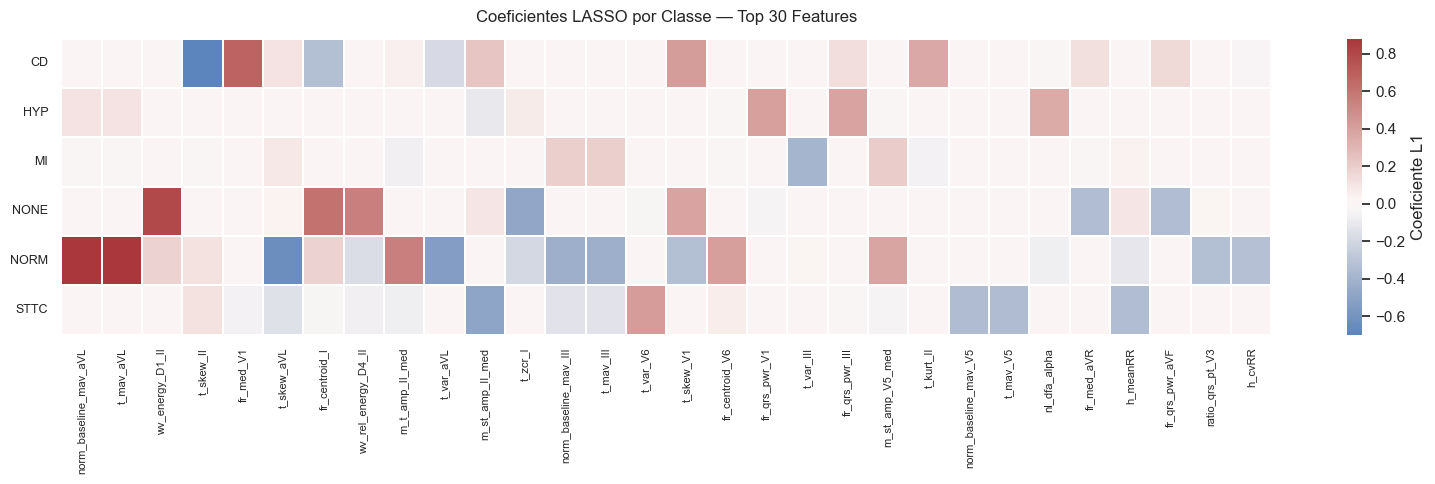

In [68]:
# Coeficientes por classe — heatmap das top-30 features (magnitude)

top30_lasso = df_lasso.head(30)['feature'].tolist()
idx_top30   = [feature_cols.index(f) for f in top30_lasso]
coef_top30  = coefs[:, idx_top30]

labels_abbr = [f.replace('_median','_med').replace('_power','_pwr')
                .replace('wavelet_','wv_').replace('nonlin_','nl_')
                .replace('freq_','fr_').replace('time_','t_')
                .replace('morph_','m_').replace('hrv_','h_')
               for f in top30_lasso]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(coef_top30, cmap='vlag', center=0,
            yticklabels=lasso_cv.classes_,
            xticklabels=labels_abbr,
            cbar_kws={'label': 'Coeficiente L1'},
            linewidths=0.2, ax=ax)
ax.set_title('Coeficientes LASSO por Classe — Top 30 Features', fontsize=12, pad=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_lasso_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()


In [69]:
# Heatmap textual dos coeficientes LASSO (top-30)

classes_lasso = [str(c) for c in lasso_cv.classes_]

df_lasso_hm = pd.DataFrame(
    coef_top30.T,
    index=top30_lasso,
    columns=classes_lasso
)

print('\nCoeficientes LASSO por Classe — Top 30 Features\n')

# Cabeçalho
header = f'{"Feature":45s}'
for c in classes_lasso:
    header += f'{c:>12s}'
print(header)
print('-' * len(header))

# Linhas
for feature, row in df_lasso_hm.iterrows():
    line = f'{feature:45s}'

    for val in row:
        line += f'{val:12.4f}'

    print(line)


Coeficientes LASSO por Classe — Top 30 Features

Feature                                                CD         HYP          MI        NONE        NORM        STTC
---------------------------------------------------------------------------------------------------------------------
norm_baseline_mav_aVL                              0.0000      0.1058     -0.0243      0.0000      0.8812      0.0000
time_mav_aVL                                       0.0000      0.1058     -0.0243      0.0000      0.8812      0.0000
wavelet_energy_D1_II                               0.0000      0.0000      0.0000      0.7968      0.1816      0.0000
time_skew_II                                      -0.6980      0.0000     -0.0113      0.0000      0.1157      0.1101
freq_median_V1                                     0.6815      0.0000      0.0000      0.0000      0.0000     -0.0614
time_skew_aVL                                      0.1039      0.0000      0.0883      0.0351     -0.6338     -0.1472
freq_c

**Comentários sobre a subseção 5.1 — LASSO:**

* O LASSO zerou relativamente poucas features: apenas 36 de 282 foram eliminadas (246 permaneceram ativas). Isso sugere que o conjunto de features possui informação distribuída entre múltiplos domínios, com redundância moderada, mas não extrema. Em outras palavras, muitas features ainda contribuem para a separação das superclasses cardíacas.

* O valor ótimo encontrado por cross-validation foi ( C = 0.1 ) (( \lambda = 10 )), indicando uma regularização relativamente forte. Isso mostra que o modelo precisou penalizar significativamente os coeficientes para evitar sobreajuste, sugerindo um problema de classificação relativamente complexo e com features parcialmente correlacionadas.

* O heatmap evidencia diversas features com sinais opostos entre classes. Por exemplo, `time_skew_aVL` apresenta coeficiente negativo para NORM e positivo para CD/STTC, enquanto `freq_centroid_I` é positivo para uma classe e negativo para CD. Esse comportamento indica que as features possuem capacidade discriminativa bidirecional — não apenas identificando uma classe específica, mas também afastando outras.

* Algumas classes apresentam coeficientes de maior magnitude e maior concentração de features relevantes, especialmente NORM e CD. Isso sugere que essas superclasses possuem padrões mais bem definidos nas features extraídas. Já classes como HYP e MI aparentam utilizar coeficientes menores e mais distribuídos, indicando separação potencialmente mais difícil ou dependente de combinações sutis de features.

* As features mais relevantes do LASSO abrangem múltiplos domínios: temporal (`time_skew`, `time_var`, `time_mav`), espectral (`freq_centroid`, `freq_qrs_power`, `freq_median`), morfológico (`morph_t_amp`, `morph_st_amp`) e wavelet (`wavelet_energy`, `wavelet_rel_energy`). Isso reforça que a discriminação das superclasses cardíacas depende de características complementares do ECG, e não de um único domínio isolado.


### 5.2 Importância por Random Forest

O **Random Forest** é um ensemble de árvores de decisão treinadas sobre subamostras do dataset e subconjuntos aleatórios de features. A importância de cada feature é calculada como a **redução média ponderada de impureza (Gini)** ao longo de todas as árvores e divisões onde a feature foi utilizada.

Essa métrica tem uma propriedade interessante: captura tanto efeitos principais quanto interações, pois as árvores podem usar múltiplas features em conjunto para definir as divisões. Por outro lado, é conhecida por inflar a importância de features com alta cardinalidade ou alta variância — o que justifica analisá-la em conjunto com os outros métodos.

Utilizamos 300 árvores (`n_estimators=300`), com profundidade máxima controlada para evitar árvores degeneradas, e `class_weight='balanced'` para lidar com o desbalanceamento entre as classes.


In [71]:
# Random Forest — importância por impureza de Gini

rf_features_path = EMBEDDED_DIR / 'embedded_rf_features.parquet'
rf_meta_path     = EMBEDDED_DIR / 'embedded_rf_metadata.parquet'
rf_import_path   = EMBEDDED_DIR / 'embedded_rf_importances.npy'

if (
    rf_features_path.exists() and
    rf_meta_path.exists() and
    rf_import_path.exists()
):
    print('Resultados do Random Forest encontrados em disco. Carregando...')
    print()

    df_rf = pd.read_parquet(rf_features_path)
    df_rf_meta = pd.read_parquet(rf_meta_path)
    importancias = np.load(rf_import_path)

    acc_rf = df_rf_meta['acc_treino'].iloc[0]

else:
    print('Treinando Random Forest para importância de features...')

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_treino, y_treino_raw)

    importancias = rf.feature_importances_

    df_rf = pd.DataFrame({
        'feature'    : feature_cols,
        'importancia': importancias,
    }).sort_values('importancia', ascending=False).reset_index(drop=True)

    df_rf['rank_rf'] = df_rf.index + 1

    acc_rf = rf.score(X_treino, y_treino_raw)

print('Top 20 features por importância (RF):')
display(df_rf.head(20).round(6))
print()

print(f'Acurácia RF no treino          : {acc_rf:.4f}')
print(f'Importância acumulada top-20  : {df_rf.head(20)["importancia"].sum()*100:.1f}%')
print(f'Importância acumulada top-50  : {df_rf.head(50)["importancia"].sum()*100:.1f}%')

Treinando Random Forest para importância de features...
Top 20 features por importância (RF):


,feature,importancia,rank_rf
0,morph_t_amp_V5_median,0.029765,1
1,morph_t_amp_II_median,0.021601,2
2,time_skew_II,0.014053,3
3,time_skew_aVL,0.009884,4
4,morph_r_amp_V5_std,0.009268,5
5,wavelet_energy_D1_II,0.008910,6
6,time_mav_III,0.008847,7
7,time_var_aVF,0.008843,8
8,hrv_meanRR,0.008058,9
9,freq_total_power_aVF,0.007881,10



Acurácia RF no treino          : 0.8882
Importância acumulada top-20  : 20.1%
Importância acumulada top-50  : 37.6%


In [72]:
# Persistência dos resultados do Random Forest

# Tempo de execução (preencher manualmente, se desejar)
tempo_rf_min = 0.30

# DataFrame consolidado
df_rf_save = df_rf.copy()
df_rf_save['selected_rf'] = True

# Metadados resumidos
df_rf_meta = pd.DataFrame({
    'n_estimators'      : [300],
    'max_depth'         : [15],
    'min_samples_leaf' : [5],
    'class_weight'      : ['balanced'],
    'n_features_total'  : [len(feature_cols)],
    'acc_treino'        : [rf.score(X_treino, y_treino_raw)],
    'top20_import_sum'  : [df_rf.head(20)['importancia'].sum()],
    'top50_import_sum'  : [df_rf.head(50)['importancia'].sum()],
    'tempo_exec_min'    : [tempo_rf_min]
})

# Salvamento
df_rf_save.to_parquet(
    EMBEDDED_DIR / 'embedded_rf_features.parquet',
    index=False
)

df_rf_meta.to_parquet(
    EMBEDDED_DIR / 'embedded_rf_metadata.parquet',
    index=False
)

# Importâncias puras (numpy)
np.save(
    EMBEDDED_DIR / 'embedded_rf_importances.npy',
    importancias
)

print('Resultados do Random Forest salvos com sucesso:')
print(' - embedded_rf_features.parquet')
print(' - embedded_rf_metadata.parquet')
print(' - embedded_rf_importances.npy')

Resultados do Random Forest salvos com sucesso:
 - embedded_rf_features.parquet
 - embedded_rf_metadata.parquet
 - embedded_rf_importances.npy


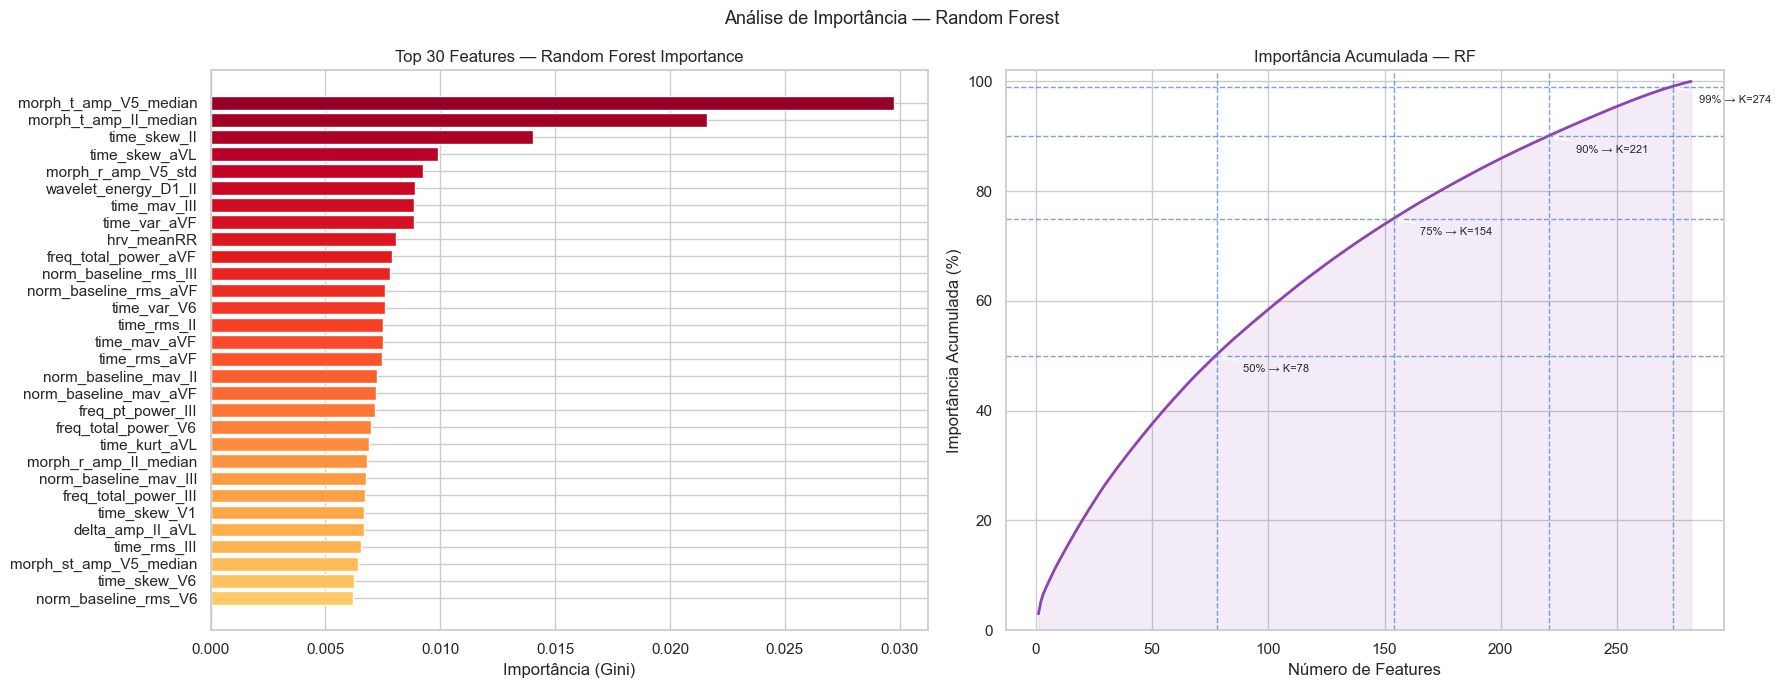

In [73]:
# Barplot Top 30 RF + curva de importância acumulada

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

top30_rf = df_rf.head(30)
ax1.barh(top30_rf['feature'][::-1], top30_rf['importancia'][::-1],
         color=plt.cm.YlOrRd(np.linspace(0.3, 0.95, 30)))
ax1.set_xlabel('Importância (Gini)')
ax1.set_title('Top 30 Features — Random Forest Importance', fontsize=12)

# Importância acumulada
imp_cum = df_rf['importancia'].cumsum()
ax2.plot(range(1, len(imp_cum)+1), imp_cum * 100, '-', color='#8e44ad', lw=2)
ax2.fill_between(range(1, len(imp_cum)+1), imp_cum * 100, alpha=0.1, color='#8e44ad')
for lim in [50, 75, 90, 99]:
    k = int(np.argmax(imp_cum >= lim/100) + 1)
    ax2.axhline(lim, ls='--', lw=1, alpha=0.7)
    ax2.axvline(k, ls='--', lw=1, alpha=0.7)
    ax2.annotate(f'{lim}% → K={k}', xy=(k, lim),
                 xytext=(k + len(feature_cols)*0.04, lim - 3),
                 fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))
ax2.set_xlabel('Número de Features')
ax2.set_ylabel('Importância Acumulada (%)')
ax2.set_title('Importância Acumulada — RF', fontsize=12)
ax2.set_ylim(0, 102)

plt.suptitle('Análise de Importância — Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_rf_importancia.png', dpi=150, bbox_inches='tight')
plt.show()


In [74]:
# Resumo textual da importância por Random Forest

print('Top 30 features — Random Forest')
print('-' * 60)

for i, row in top30_rf.reset_index(drop=True).iterrows():
    print(f'{i+1:2d}. {row["feature"]:<40} {row["importancia"]:.6f}')

print()
print('Importância acumulada')
print('-' * 60)

imp_cum = df_rf['importancia'].cumsum()

for lim in [50, 75, 90, 95, 99]:
    k = int(np.argmax(imp_cum >= lim/100) + 1)
    print(f'{lim:2d}% da importância acumulada atingidos com K = {k} features')

Top 30 features — Random Forest
------------------------------------------------------------
 1. morph_t_amp_V5_median                    0.029765
 2. morph_t_amp_II_median                    0.021601
 3. time_skew_II                             0.014053
 4. time_skew_aVL                            0.009884
 5. morph_r_amp_V5_std                       0.009268
 6. wavelet_energy_D1_II                     0.008910
 7. time_mav_III                             0.008847
 8. time_var_aVF                             0.008843
 9. hrv_meanRR                               0.008058
10. freq_total_power_aVF                     0.007881
11. norm_baseline_rms_III                    0.007797
12. norm_baseline_rms_aVF                    0.007615
13. time_var_V6                              0.007589
14. time_rms_II                              0.007511
15. time_mav_aVF                             0.007492
16. time_rms_aVF                             0.007458
17. norm_baseline_mav_II                   

**Comentários sobre a subseção 5.2 — Random Forest:**

* A curva de importância acumulada apresenta comportamento relativamente gradual. Embora algumas features tenham importância claramente superior (`morph_t_amp_V5_median`, `morph_t_amp_II_median`, `time_skew_II`), a importância total permanece distribuída ao longo de muitas variáveis. Isso indica que o problema depende de múltiplas características complementares, e não apenas de um pequeno núcleo dominante de features.

* Foram necessárias aproximadamente 221 features para acumular 90% da importância total da floresta. Esse valor é bastante elevado em relação ao número total de 282 features, sugerindo que a Random Forest distribui relevância entre muitos atributos. Comparando com o PCA do E8, isso evidencia a diferença entre compressão e seleção: o PCA concentra variância em poucos componentes lineares, enquanto a RF preserva múltiplas variáveis potencialmente úteis para decisões não-lineares.

* Features relacionadas a HRV e medidas estatísticas mais complexas aparecem entre as mais importantes da RF, como `hrv_meanRR`, `time_skew`, `time_kurt` e métricas de baseline normalizado. Isso é coerente com a natureza do método: árvores conseguem explorar interações e limiares não-lineares que métodos lineares univariados, como ANOVA, tendem a ignorar.

* Há concordância parcial entre Random Forest e LASSO. Features como `morph_t_amp_V5_median`, `morph_t_amp_II_median`, `time_skew_II`, `time_skew_aVL`, `wavelet_energy_D1_II`, `freq_total_power_III` e `time_skew_V1` aparecem com destaque em ambos os métodos. Essa interseção é particularmente relevante, pois combina evidências provenientes de modelos com naturezas distintas — um linear e esparso (LASSO) e outro não-linear baseado em ensembles (RF).

* O ranking da RF também reforça a importância de múltiplos domínios de análise. As top features incluem características morfológicas (`morph_*`), temporais (`time_*`), espectrais (`freq_*`), wavelet e HRV, indicando novamente que a discriminação das superclasses cardíacas depende de informações complementares extraídas do ECG.

---

## 6. Validação Estatística por Feature

### Fundamentação

Os métodos de seleção das seções anteriores fornecem rankings e subconjuntos candidatos, mas não garantem formalmente que as diferenças observadas entre classes sejam estatisticamente significativas. Esta seção realiza a **validação estatística individual de cada feature candidata**, aplicando testes de hipótese, correção para múltiplas comparações e cálculo de effect size.

Os três passos desta seção são:

1. **Testes de hipótese por feature:** verificar se as distribuições da feature diferem significativamente entre as classes. Usamos o **Kruskal-Wallis** (extensão não-paramétrica da ANOVA de uma via para $C > 2$ classes), que não exige normalidade e é robusto a assimetrias — características comuns em features de biossinais.

2. **Correção de múltiplas comparações:** ao testar centenas de features simultaneamente, a probabilidade de rejeitar incorretamente $H_0$ aumenta linearmente com o número de testes (problema do *p-value inflation*). Aplicamos duas estratégias de correção: **Bonferroni** (controla o FWER — Family-Wise Error Rate — de forma conservadora) e **FDR de Benjamini-Hochberg** (controla a proporção esperada de falsos positivos — mais liberal e com maior poder estatístico).

3. **Effect size (Eta-quadrado $\eta^2$):** um p-value pequeno confirma que a diferença é real, mas não diz se ela é *relevante*. O effect size quantifica a magnitude do efeito — aqui usamos o **Eta-quadrado** ($\eta^2$), interpretável como a proporção da variância total explicada pela classe.


### 6.1 Testes de Hipótese por Feature — Kruskal-Wallis

O **teste de Kruskal-Wallis** testa a hipótese nula de que as distribuições de uma variável contínua são idênticas entre $C$ grupos. É equivalente não-paramétrico da ANOVA e robusto a violações de normalidade e homocedasticidade — frequentes em features de ECG, especialmente as não-lineares.

$$H = \frac{12}{N(N+1)} \sum_{c=1}^{C} \frac{R_c^2}{n_c} - 3(N+1)$$

onde $R_c$ é a soma dos ranks do grupo $c$ e $n_c$ é o número de amostras nesse grupo. Sob $H_0$, $H$ segue aproximadamente uma distribuição $\chi^2$ com $C-1$ graus de liberdade.

Por eficiência computacional, aplicamos o teste sobre o subconjunto de features presentes em pelo menos um dos métodos de seleção das seções anteriores.


In [75]:
# Kruskal-Wallis por feature — aplicado sobre candidatas pré-selecionadas

# Reúne todas as features candidatas (união dos métodos anteriores)
candidatas_set = (
    set(df_filter_final.head(80)['feature'].tolist()) |  # top-80 filtros
    set(features_sfs) |
    set(features_sbe) |
    set(df_lasso.head(60)['feature'].tolist()) |
    set(df_rf.head(60)['feature'].tolist())
)
candidatas = sorted(candidatas_set)
print(f'Total de features candidatas para validação estatística: {len(candidatas)}')

# Distribui as amostras por classe (treino)
grupos_por_classe = {
    cls: df_treino.loc[df_treino['primary_class'] == cls, candidatas].values
    for cls in classes_ok
}

resultados_kw = []
for feat in candidatas:
    feat_to_idx = {f:i for i,f in enumerate(candidatas)}
    feat_idx = feat_to_idx[feat]
    grupos   = [grupos_por_classe[cls][:, feat_idx] for cls in classes_ok]

    try:
        stat, p = kruskal(*grupos)
    except Exception:
        stat, p = np.nan, np.nan

    resultados_kw.append({'feature': feat, 'H_stat': stat, 'p_kruskal': p})

df_kw = pd.DataFrame(resultados_kw).sort_values('p_kruskal').reset_index(drop=True)

print(f'\nFeatures com p < 0.05 (Kruskal-Wallis) : {(df_kw["p_kruskal"] < 0.05).sum()}')
print(f'Features com p < 0.01                  : {(df_kw["p_kruskal"] < 0.01).sum()}')
print(f'Features com p < 0.001                 : {(df_kw["p_kruskal"] < 0.001).sum()}')
print()
display(df_kw.head(20).round(6))


Total de features candidatas para validação estatística: 127

Features com p < 0.05 (Kruskal-Wallis) : 127
Features com p < 0.01                  : 127
Features com p < 0.001                 : 127



,feature,H_stat,p_kruskal
0,delta_amp_II_aVL,2563.732779,0.0
1,delta_amp_I_aVR,2732.223381,0.0
2,freq_centroid_V1,1587.015530,0.0
3,freq_median_V1,1576.590689,0.0
4,freq_pt_power_III,2738.812730,0.0
5,freq_qrs_power_III,2039.032130,0.0
6,freq_pt_power_aVR,2258.659482,0.0
7,freq_pt_power_V6,1498.450044,0.0
8,freq_qrs_power_aVL,1867.337876,0.0
9,freq_qrs_power_aVR,1833.611312,0.0


### 6.2 Correção de Múltiplas Comparações

Ao realizar $M$ testes simultaneamente, a probabilidade de obter pelo menos um falso positivo sob $H_0$ global é:

$$P(\text{ao menos 1 FP}) = 1 - (1 - \alpha)^M$$

Para $M = 200$ e $\alpha = 0.05$: $P(\text{FP}) \approx 99.9\%$. Portanto, corrigir para múltiplas comparações não é uma formalidade — é uma necessidade para que os p-values tenham alguma validade.

Duas estratégias complementares são aplicadas:

- **Bonferroni:** divide o limiar $\alpha$ por $M$ ($\alpha_{\text{corr}} = \alpha / M$). Controla o FWER, mas é muito conservador — features com p-values moderados podem ser descartadas mesmo sendo relevantes.
- **Benjamini-Hochberg (FDR):** controla a proporção esperada de falsos positivos (False Discovery Rate). Mais liberal e com maior poder estatístico que Bonferroni. Em estudos exploratórios como este, é o método preferido.


In [76]:
# Correção de Bonferroni e FDR (Benjamini-Hochberg)

p_vals_array = df_kw['p_kruskal'].fillna(1.0).values

# Bonferroni
_, p_bonf, _, _  = multipletests(p_vals_array, method='bonferroni', alpha=0.05)

# Benjamini-Hochberg (FDR)
_, p_fdr, _, _   = multipletests(p_vals_array, method='fdr_bh', alpha=0.05)

df_kw['p_bonferroni']  = p_bonf
df_kw['p_fdr_bh']      = p_fdr
df_kw['sig_bonf']      = p_bonf < 0.05
df_kw['sig_fdr']       = p_fdr  < 0.05

print('Resumo após correção para múltiplas comparações:')
print(f'  Significativas por Bonferroni (FWER < 5%) : {df_kw["sig_bonf"].sum()} features')
print(f'  Significativas por FDR-BH (FDR < 5%)      : {df_kw["sig_fdr"].sum()} features')
print()
print('Top 20 features após correção:')
display(df_kw[['feature', 'H_stat', 'p_kruskal',
               'p_bonferroni', 'p_fdr_bh', 'sig_bonf', 'sig_fdr']].head(20).round(6))


Resumo após correção para múltiplas comparações:
  Significativas por Bonferroni (FWER < 5%) : 127 features
  Significativas por FDR-BH (FDR < 5%)      : 127 features

Top 20 features após correção:


,feature,H_stat,p_kruskal,p_bonferroni,p_fdr_bh,sig_bonf,sig_fdr
0,delta_amp_II_aVL,2563.732779,0.0,0.0,0.0,True,True
1,delta_amp_I_aVR,2732.223381,0.0,0.0,0.0,True,True
2,freq_centroid_V1,1587.015530,0.0,0.0,0.0,True,True
3,freq_median_V1,1576.590689,0.0,0.0,0.0,True,True
4,freq_pt_power_III,2738.812730,0.0,0.0,0.0,True,True
5,freq_qrs_power_III,2039.032130,0.0,0.0,0.0,True,True
6,freq_pt_power_aVR,2258.659482,0.0,0.0,0.0,True,True
7,freq_pt_power_V6,1498.450044,0.0,0.0,0.0,True,True
8,freq_qrs_power_aVL,1867.337876,0.0,0.0,0.0,True,True
9,freq_qrs_power_aVR,1833.611312,0.0,0.0,0.0,True,True


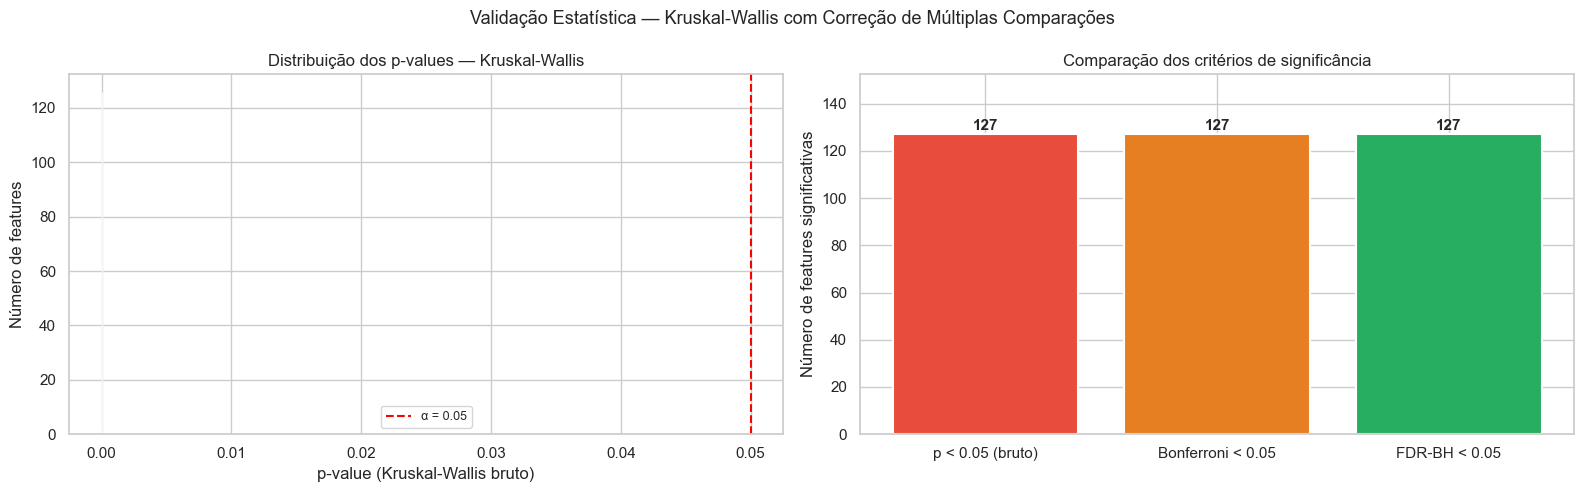

In [77]:
# Visualização — distribuição dos p-values e comparação dos critérios de significância

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma dos p-values brutos
axes[0].hist(df_kw['p_kruskal'].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0.05, color='red', ls='--', lw=1.5, label='α = 0.05')
axes[0].set_xlabel('p-value (Kruskal-Wallis bruto)')
axes[0].set_ylabel('Número de features')
axes[0].set_title('Distribuição dos p-values — Kruskal-Wallis')
axes[0].legend(fontsize=9)

# Comparação dos critérios
criterios  = ['p < 0.05 (bruto)', 'Bonferroni < 0.05', 'FDR-BH < 0.05']
n_sig      = [
    (df_kw['p_kruskal'] < 0.05).sum(),
    df_kw['sig_bonf'].sum(),
    df_kw['sig_fdr'].sum()
]
cores_bar = ['#e74c3c', '#e67e22', '#27ae60']
bars = axes[1].bar(criterios, n_sig, color=cores_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, n_sig):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Número de features significativas')
axes[1].set_title('Comparação dos critérios de significância')
axes[1].set_ylim(0, max(n_sig) * 1.2)

plt.suptitle('Validação Estatística — Kruskal-Wallis com Correção de Múltiplas Comparações', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_pvalues_correcao.png', dpi=150, bbox_inches='tight')
plt.show()


**Comentários sobre a subseção 6.2 — Correção de Múltiplas Comparações:**

* A correção de Bonferroni não reduziu o número de features significativas em relação ao FDR-BH: as 127 features candidatas permaneceram significativas em ambos os critérios. Isso indica que os p-values obtidos pelo teste de Kruskal-Wallis eram extremamente pequenos, muito abaixo dos limiares corrigidos, evidenciando forte separação estatística entre as classes.

* A distribuição dos p-values brutos ficou fortemente concentrada próxima de zero, sem apresentar a região aproximadamente uniforme normalmente esperada sob mistura entre hipóteses nulas e alternativas. Visualmente, o histograma praticamente colapsou no primeiro intervalo de valores devido à magnitude extremamente pequena dos p-values obtidos. Isso sugere que o subconjunto de features previamente selecionado pelos métodos de seleção já continha majoritariamente features altamente discriminativas.

* O fato de Bonferroni e FDR-BH produzirem exatamente o mesmo conjunto de features significativas mostra que a evidência estatística permaneceu robusta mesmo sob critérios extremamente conservadores. Em datasets mais ruidosos ou menos pré-filtrados, seria esperado que Bonferroni eliminasse uma quantidade maior de features.

* A partir deste ponto, o critério de FDR-BH ainda será preferido para análises exploratórias subsequentes, por possuir maior poder estatístico e menor tendência a descartar features potencialmente relevantes. Entretanto, neste estudo específico, a diferença prática entre Bonferroni e FDR-BH tornou-se desprezível devido à magnitude extremamente baixa dos p-values observados.

* Como praticamente todas as features candidatas permaneceram estatisticamente significativas após correção, o principal desafio passa a não ser mais identificar relevância estatística, mas sim compreender redundâncias, correlações e interpretabilidade fisiológica entre as features selecionadas.


### 6.3 Effect Size — Eta-quadrado ($\eta^2$)

Um p-value estatisticamente significativo confirma que diferenças existem entre as classes, mas não informa sua **magnitude prática**. Em datasets grandes como o PTB-XL, diferenças pequenas podem atingir significância estatística apenas devido ao elevado número de amostras. O *effect size* é a medida que permite avaliar se essas diferenças são realmente relevantes do ponto de vista prático e discriminativo.

Para o teste de Kruskal-Wallis, utilizamos uma aproximação do **Eta-quadrado** ($\eta^2$), calculada por:

$\Large{\eta^2 = \frac{H - (C - 1)}{N - C}}$

onde:

* (H) é a estatística de Kruskal-Wallis;
* (C) é o número de classes;
* (N) é o número total de observações.

Essa métrica fornece uma estimativa da fração da variabilidade associada às diferenças entre classes, funcionando como uma medida de intensidade do efeito observado.

Interpretação convencional (Cohen, 1988):

* $\eta^2 < 0.01$: efeito negligenciável
* $0.01 \leq \eta^2 < 0.06$: efeito pequeno
* $0.06 \leq \eta^2 < 0.14$: efeito médio
* $\eta^2 \geq 0.14$: efeito grande

No contexto deste estudo, o effect size é particularmente importante porque praticamente todas as features candidatas apresentaram significância estatística após correção para múltiplas comparações. Assim, o ($\eta^2$) torna-se mais informativo do que o próprio p-value para distinguir features com maior relevância discriminativa.


In [78]:
# Cálculo do Eta-quadrado para cada feature candidata

C_classes = len(classes_ok)
N_total   = mask_treino.sum()

df_kw['eta_squared'] = (df_kw['H_stat'] - (C_classes - 1)) / (N_total - C_classes)
df_kw['eta_squared'] = df_kw['eta_squared'].clip(lower=0)   # clip em 0 — valores negativos são artefatos numéricos

# Classificação do effect size
def classifica_eta(eta):
    if eta < 0.01:   return 'Negligenciável'
    elif eta < 0.06: return 'Pequeno'
    elif eta < 0.14: return 'Médio'
    else:            return 'Grande'

df_kw['effect_size_cat'] = df_kw['eta_squared'].apply(classifica_eta)

print('Distribuição das features por categoria de effect size:')
display(df_kw['effect_size_cat'].value_counts().rename_axis('Categoria').reset_index(name='N'))

print()
print('Top 20 features por Eta-quadrado (effect size):')
display(
    df_kw.sort_values('eta_squared', ascending=False)
    [['feature', 'H_stat', 'p_fdr_bh', 'eta_squared', 'effect_size_cat']]
    .head(20)
    .round(5)
)


Distribuição das features por categoria de effect size:


,Categoria,N
0,Médio,79
1,Grande,28
2,Pequeno,18
3,Negligenciável,2



Top 20 features por Eta-quadrado (effect size):


,feature,H_stat,p_fdr_bh,eta_squared,effect_size_cat
18,morph_t_amp_V5_median,3731.45887,0.0,0.26183,Grande
19,morph_t_amp_II_median,3531.96906,0.0,0.24782,Grande
36,time_skew_II,2888.96791,0.0,0.20265,Grande
4,freq_pt_power_III,2738.81273,0.0,0.19211,Grande
1,delta_amp_I_aVR,2732.22338,0.0,0.19164,Grande
26,morph_qrs_width_ms_V5_median,2707.79924,0.0,0.18993,Grande
24,morph_r_amp_II_median,2661.97203,0.0,0.18671,Grande
15,freq_total_power_III,2648.87038,0.0,0.18579,Grande
22,norm_baseline_mav_III,2634.44383,0.0,0.18477,Grande
51,time_mav_III,2634.44383,0.0,0.18477,Grande


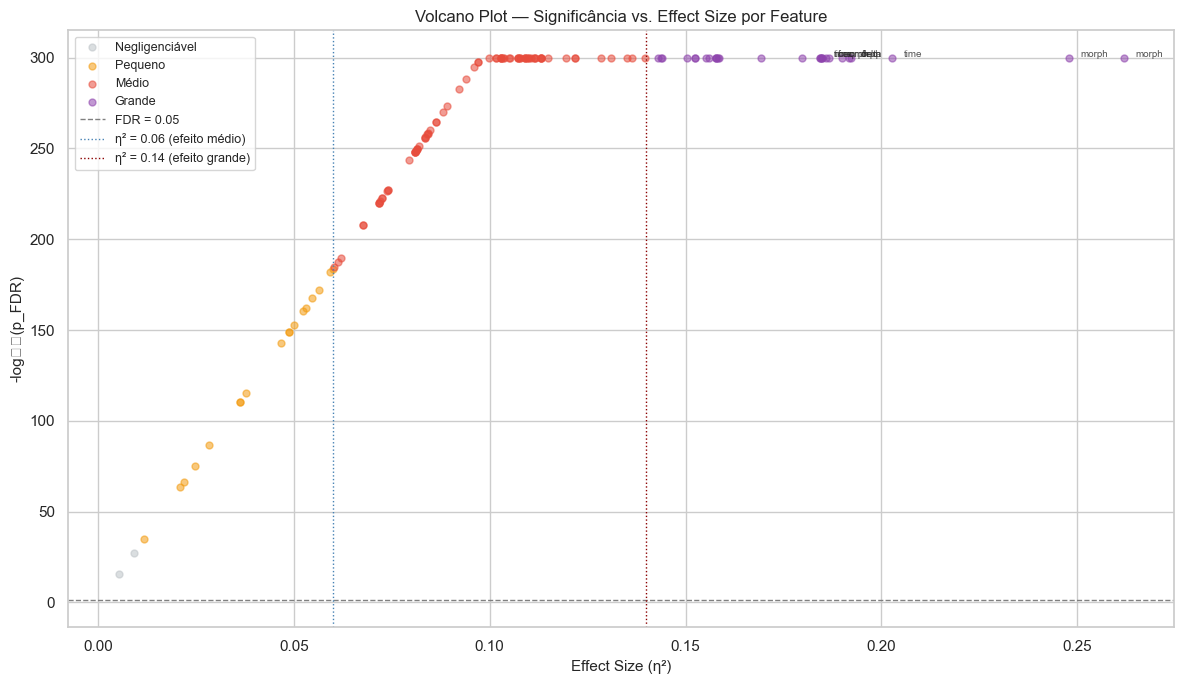

In [79]:
# Scatter: -log10(p_fdr) vs. eta_squared — equivalente ao volcano plot

df_kw_plot = df_kw.dropna(subset=['p_fdr_bh', 'eta_squared']).copy()
df_kw_plot['log10p'] = -np.log10(df_kw_plot['p_fdr_bh'].clip(lower=1e-300))

# Cores por effect size
cores_es = {
    'Negligenciável': '#bdc3c7',
    'Pequeno'       : '#f39c12',
    'Médio'         : '#e74c3c',
    'Grande'        : '#8e44ad',
}

fig, ax = plt.subplots(figsize=(12, 7))
for cat, cor in cores_es.items():
    mask_c = df_kw_plot['effect_size_cat'] == cat
    ax.scatter(df_kw_plot.loc[mask_c, 'eta_squared'],
               df_kw_plot.loc[mask_c, 'log10p'],
               alpha=0.55, s=25, color=cor, label=cat, rasterized=True)

ax.axhline(-np.log10(0.05), color='gray', ls='--', lw=1, label='FDR = 0.05')
ax.axvline(0.06, color='steelblue', ls=':', lw=1, label='η² = 0.06 (efeito médio)')
ax.axvline(0.14, color='darkred', ls=':', lw=1, label='η² = 0.14 (efeito grande)')
ax.set_xlabel('Effect Size (η²)', fontsize=11)
ax.set_ylabel('-log₁₀(p_FDR)', fontsize=11)
ax.set_title('Volcano Plot — Significância vs. Effect Size por Feature', fontsize=12)
ax.legend(fontsize=9, loc='upper left')

# Anota as 10 features de maior effect size
top10_es = df_kw_plot.nlargest(10, 'eta_squared')
for _, row in top10_es.iterrows():
    ax.annotate(row['feature'].split('_')[0][:10],
                xy=(row['eta_squared'], row['log10p']),
                xytext=(row['eta_squared'] + 0.003, row['log10p'] + 0.5),
                fontsize=7, alpha=0.8)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_volcano_effect_size.png', dpi=150, bbox_inches='tight')
plt.show()


In [80]:
# Volcano plot em formato textual — Significância vs Effect Size

df_kw_plot = df_kw.dropna(subset=['p_fdr_bh', 'eta_squared']).copy()
df_kw_plot['log10p'] = -np.log10(df_kw_plot['p_fdr_bh'].clip(lower=1e-300))

print('Volcano Plot — Significância vs Effect Size')
print('-' * 90)
print(f'{"Feature":40s} {"η²":>10s} {"-log10(p_FDR)":>18s} {"Categoria":>18s}')
print('-' * 90)

top30_volcano = (
    df_kw_plot
    .sort_values(['eta_squared', 'log10p'], ascending=False)
    .head(30)
)

for _, row in top30_volcano.iterrows():
    print(f'{row["feature"][:40]:40s} '
          f'{row["eta_squared"]:10.4f} '
          f'{row["log10p"]:18.2f} '
          f'{row["effect_size_cat"]:>18s}')

print()
print('Resumo por categoria de effect size')
print('-' * 90)

contagem_es = (
    df_kw_plot['effect_size_cat']
    .value_counts()
    .reindex(['Grande', 'Médio', 'Pequeno', 'Negligenciável'])
    .fillna(0)
    .astype(int)
)

for cat, n in contagem_es.items():
    pct = 100 * n / len(df_kw_plot)
    print(f'{cat:18s}: {n:3d} features ({pct:5.1f}%)')

print()
print('Thresholds de referência:')
print(f'  η² >= 0.14  -> efeito grande')
print(f'  η² >= 0.06  -> efeito médio')
print(f'  FDR < 0.05  -> significativo')

Volcano Plot — Significância vs Effect Size
------------------------------------------------------------------------------------------
Feature                                          η²      -log10(p_FDR)          Categoria
------------------------------------------------------------------------------------------
morph_t_amp_V5_median                        0.2618             300.00             Grande
morph_t_amp_II_median                        0.2478             300.00             Grande
time_skew_II                                 0.2027             300.00             Grande
freq_pt_power_III                            0.1921             300.00             Grande
delta_amp_I_aVR                              0.1916             300.00             Grande
morph_qrs_width_ms_V5_median                 0.1899             300.00             Grande
morph_r_amp_II_median                        0.1867             300.00             Grande
freq_total_power_III                         0.1858   

**Comentários sobre a subseção 6.3 — Effect Size:**

* A maioria das features apresentou effect size relevante: 79 features foram classificadas como efeito médio e 28 como efeito grande, totalizando 107 features (84.2%) com magnitude prática substancial. Isso indica que as diferenças entre classes não são apenas estatisticamente detectáveis, mas também suficientemente fortes para terem utilidade discriminativa real.

* O volcano plot mostrou um padrão bastante consistente: praticamente todas as features possuem p-values extremamente baixos simultaneamente a effect sizes moderados ou altos. Não houve um grupo relevante de features com significância estatística alta porém efeito desprezível, o que sugere que os resultados não são apenas consequência do grande tamanho amostral do PTB-XL. As features mais relevantes concentraram-se na região superior direita do gráfico — combinação de alta significância e alto η².

* As features com maior effect size coincidem fortemente com aquelas destacadas pelos métodos anteriores (SFS, SBE, LASSO e Random Forest). Features como `morph_t_amp_V5_median`, `morph_t_amp_II_median`, `time_skew_II`, `freq_pt_power_III`, `freq_total_power_III` e `freq_qrs_power_III` apareceram repetidamente entre os melhores rankings e também apresentaram η² elevado. Essa concordância entre múltiplos métodos aumenta substancialmente a confiança de que essas features possuem relevância fisiológica e discriminativa genuína.

* Apenas 2 features foram classificadas com effect size negligenciável, apesar de permanecerem estatisticamente significativas após correção FDR e Bonferroni. Isso é coerente com o tamanho do dataset: amostras grandes tornam o teste extremamente sensível a pequenas diferenças. Na prática, essas features negligenciáveis seriam candidatas naturais para descarte, pois apresentam baixa contribuição discriminativa mesmo com p-value muito pequeno.


---

## 7. Consolidação e Ranking Final dos Atributos

Com todos os métodos aplicados — três filtros, dois wrappers, dois embedded e validação estatística formal — chegamos à etapa de consolidação. O objetivo é construir um **ranking final unificado** que reflita o consenso entre diferentes perspectivas de relevância, combinando capacidade discriminativa, robustez estatística e estabilidade entre métodos.

A estratégia adotada consiste em um **ranking agregado ponderado inspirado em Borda Count**: para cada método, calcula-se a posição (*rank*) da feature naquele critério, e o rank final é obtido pela combinação ponderada dos ranks individuais. Dessa forma, features consistentemente bem posicionadas em múltiplos métodos são favorecidas em relação àquelas que aparecem no topo de apenas um critério específico.

Os pesos foram atribuídos de acordo com a natureza e abrangência de cada método:

* **Embedded Methods (LASSO e Random Forest): peso 2.0**
  Incorporam a seleção diretamente ao treinamento do modelo, capturando interações e relevância preditiva de forma mais próxima do desempenho real de classificação.

* **Wrapper Methods (SFS e SBE): peso 2.0**
  Avaliam subconjuntos completos de features utilizando um estimador, permitindo capturar dependências entre atributos, embora com espaço de busca limitado pelo custo computacional.

* **Filter Methods (ANOVA, Mutual Information e ReliefF): peso 1.5**
  Métodos rápidos e abrangentes, úteis para exploração inicial e identificação de relevância individual das features.

* **Effect Size ($\eta^2$): peso 1.5**
  Complementa os métodos anteriores ao incorporar magnitude prática das diferenças entre classes, e não apenas significância estatística.

In [83]:
# Consolidação de todos os rankings em um único DataFrame

# Referência: todas as candidatas que passaram pelo menos por um método
todas_candidatas = sorted(candidatas_set)

df_final = pd.DataFrame({'feature': todas_candidatas})

# --- Filter ---
df_final = df_final.merge(
    df_filter_final[['feature', 'rank_filter']].rename(columns={'rank_filter': 'r_filter'}),
    on='feature', how='left'
)

# --- LASSO ---
df_final = df_final.merge(
    df_lasso[['feature', 'rank_lasso']].rename(columns={'rank_lasso': 'r_lasso'}),
    on='feature', how='left'
)

# --- RF ---
df_final = df_final.merge(
    df_rf[['feature', 'rank_rf']].rename(columns={'rank_rf': 'r_rf'}),
    on='feature', how='left'
)

# --- KW + Effect size ---
df_kw_merge = df_kw.sort_values('eta_squared', ascending=False).reset_index(drop=True)
df_kw_merge['r_eta'] = df_kw_merge.index + 1

df_final = df_final.merge(
    df_kw_merge[['feature', 'r_eta', 'eta_squared', 'sig_fdr', 'p_fdr_bh']],
    on='feature', how='left'
)

# --- Wrapper (SFS + SBE) ---
# Soma dos ranks internos dos wrappers:
# features presentes em ambos tendem a receber ranks menores (melhores)

wrapper_scores = {}

for i, f in enumerate(features_sfs):
    wrapper_scores[f] = wrapper_scores.get(f, 0) + (i + 1)

for i, f in enumerate(features_sbe):
    wrapper_scores[f] = wrapper_scores.get(f, 0) + (i + 1)

df_wrapper = pd.DataFrame({
    'feature'   : list(wrapper_scores.keys()),
    'r_wrapper' : list(wrapper_scores.values())
})

df_final = df_final.merge(
    df_wrapper,
    on='feature',
    how='left'
)

# --- Preenche NaN com rank "pior caso" ---
max_rank = len(todas_candidatas) + 1

for col in ['r_filter', 'r_lasso', 'r_rf', 'r_eta']:
    df_final[col] = df_final[col].fillna(max_rank)

df_final['r_wrapper'] = df_final['r_wrapper'].fillna(max_rank)

# --- Borda Count ponderado ---
pesos = {
    'r_lasso'   : 2.0,
    'r_rf'      : 2.0,
    'r_filter'  : 1.5,
    'r_wrapper' : 2.0,
    'r_eta'     : 1.5
}

soma_pesos = sum(pesos.values())

df_final['rank_final'] = sum(
    df_final[col] * w for col, w in pesos.items()
) / soma_pesos

df_final = df_final.sort_values('rank_final').reset_index(drop=True)
df_final['posicao_final'] = df_final.index + 1

print('Top 30 features pelo ranking consolidado (Borda Count ponderado):')

display(
    df_final[
        ['posicao_final', 'feature',
         'r_filter', 'r_lasso', 'r_rf',
         'r_wrapper', 'r_eta',
         'eta_squared', 'sig_fdr',
         'rank_final']
    ]
    .head(30)
    .round(3)
)

Top 30 features pelo ranking consolidado (Borda Count ponderado):


,posicao_final,feature,r_filter,r_lasso,r_rf,r_wrapper,r_eta,eta_squared,sig_fdr,rank_final
0,1,time_skew_II,2,4.0,3,4.0,3,0.203,True,3.278
1,2,morph_t_amp_II_median,1,9.0,2,2.0,2,0.248,True,3.389
2,3,time_skew_aVL,10,6.0,4,5.0,15,0.169,True,7.500
3,4,time_mav_III,16,14.0,7,8.0,10,0.185,True,10.778
4,5,morph_t_amp_V5_median,3,41.0,1,6.0,1,0.262,True,11.333
5,6,norm_baseline_mav_III,15,13.0,23,7.0,9,0.185,True,13.556
6,7,time_skew_V1,21,16.0,25,22.0,26,0.144,True,21.833
7,8,freq_pt_power_III,48,32.0,19,19.0,4,0.192,True,24.222
8,9,morph_r_amp_II_median,6,89.0,22,4.0,7,0.187,True,27.722
9,10,time_kurt_aVL,13,68.0,21,7.0,27,0.144,True,28.000


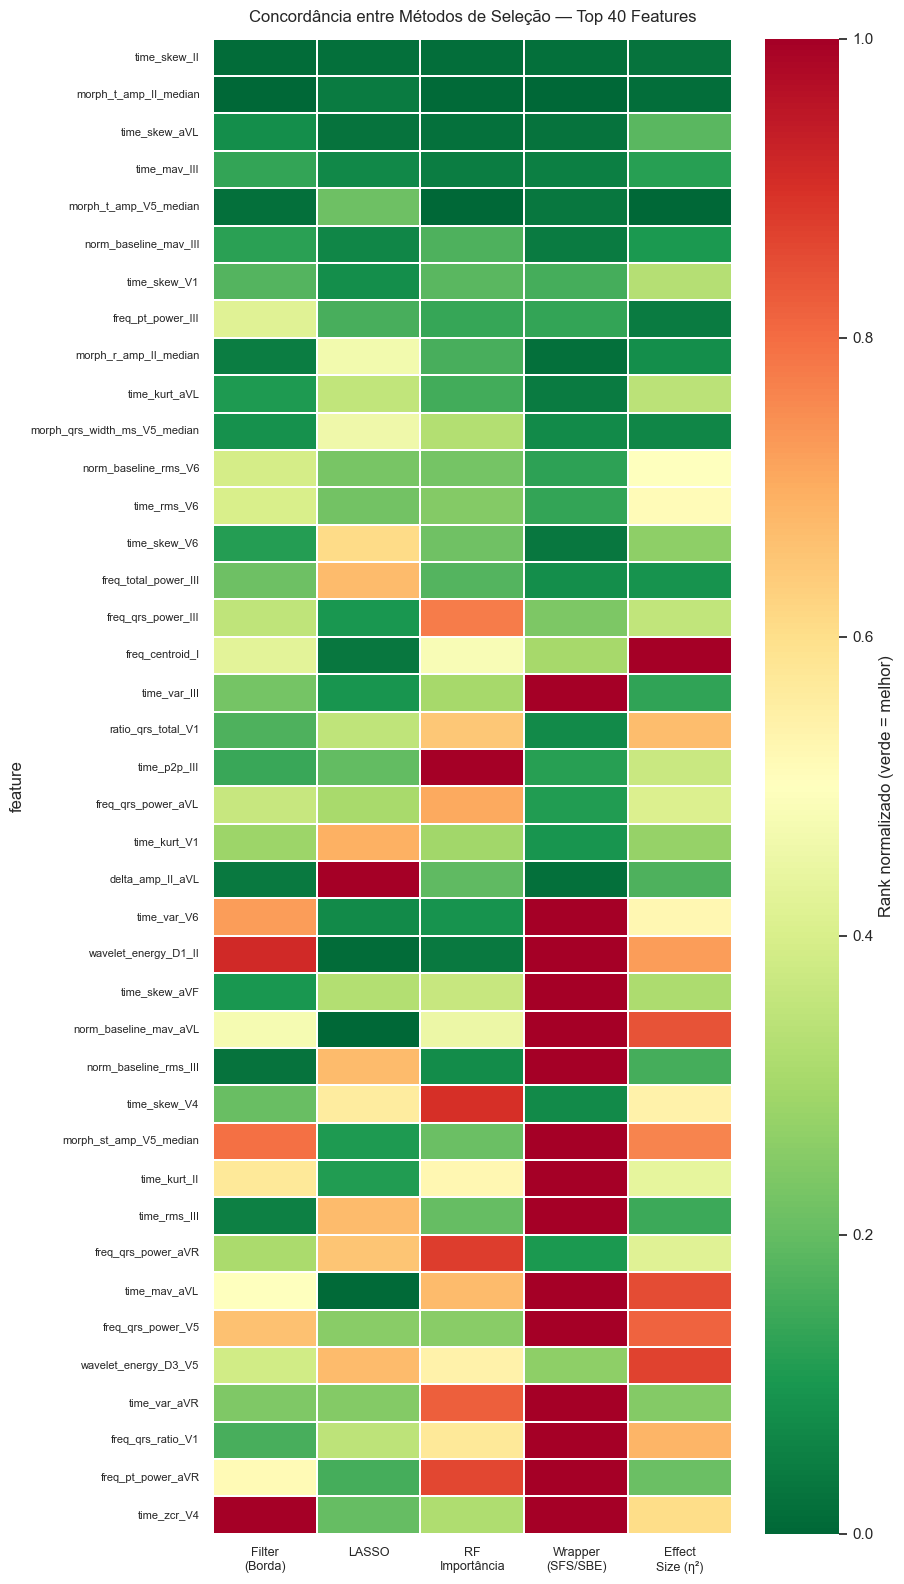

In [84]:
# Heatmap de rankings normalizados — Top 40 features finais

top40_final   = df_final.head(40)
rank_cols     = ['r_filter', 'r_lasso', 'r_rf', 'r_wrapper', 'r_eta']
rank_labels   = ['Filter\n(Borda)', 'LASSO', 'RF\nImportância', 'Wrapper\n(SFS/SBE)', 'Effect\nSize (η²)']

df_hm_final   = top40_final.set_index('feature')[rank_cols].copy()
# Normaliza cada coluna para [0,1] para visualização comparável
df_hm_norm_f  = df_hm_final.apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9))

fig, ax = plt.subplots(figsize=(9, 16))
sns.heatmap(df_hm_norm_f, cmap='RdYlGn_r', ax=ax,
            yticklabels=top40_final['feature'].tolist(),
            xticklabels=rank_labels,
            cbar_kws={'label': 'Rank normalizado (verde = melhor)'},
            linewidths=0.2, annot=False)
ax.set_title('Concordância entre Métodos de Seleção — Top 40 Features', fontsize=12, pad=12)
plt.xticks(fontsize=9)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_ranking_consolidado_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [87]:
# Análise de concordância entre métodos — quantas das top-K estão em consenso?

print('Análise de sobreposição entre os métodos (Top-K features):')
print('-' * 65)

for K in [10, 20, 30, 50]:
    top_k_final   = set(df_final.head(K)['feature'])
    top_k_filter  = set(df_filter_final.head(K)['feature'])
    top_k_lasso   = set(df_lasso.head(K)['feature'])
    top_k_rf      = set(df_rf.head(K)['feature'])
    top_k_eta     = set(df_kw.nlargest(K, 'eta_squared')['feature'])

    # Features presentes em pelo menos 3 dos 4 métodos individuais
    contagens = {}
    for f in top_k_final:
        count = sum([
            f in top_k_filter,
            f in top_k_lasso,
            f in top_k_rf,
            f in top_k_eta,
        ])
        contagens[f] = count

    consenso_3 = sum(v >= 3 for v in contagens.values())
    consenso_4 = sum(v >= 4 for v in contagens.values())

    print(f'  Top-{K:2d}: {consenso_3:2d} features em ≥3 métodos | '
          f'{consenso_4:2d} features em todos os 4 métodos')

print()
print('Features do Top-20 final em CONSENSO (≥ 3 métodos):')
K = 20
top_k_final  = set(df_final.head(K)['feature'])
top_k_filter = set(df_filter_final.head(K)['feature'])
top_k_lasso  = set(df_lasso.head(K)['feature'])
top_k_rf     = set(df_rf.head(K)['feature'])
top_k_eta    = set(df_kw.nlargest(K, 'eta_squared')['feature'])

for f in df_final.head(K)['feature']:
    c = sum([f in top_k_filter, f in top_k_lasso, f in top_k_rf, f in top_k_eta])
    marca = '✓' * c
    print(f'  {f:<55} [{marca}]  ({c}/4 métodos)')


Análise de sobreposição entre os métodos (Top-K features):
-----------------------------------------------------------------
  Top-10:  4 features em ≥3 métodos |  2 features em todos os 4 métodos
  Top-20:  6 features em ≥3 métodos |  4 features em todos os 4 métodos
  Top-30: 14 features em ≥3 métodos |  6 features em todos os 4 métodos
  Top-50: 29 features em ≥3 métodos | 11 features em todos os 4 métodos

Features do Top-20 final em CONSENSO (≥ 3 métodos):
  time_skew_II                                            [✓✓✓✓]  (4/4 métodos)
  morph_t_amp_II_median                                   [✓✓✓✓]  (4/4 métodos)
  time_skew_aVL                                           [✓✓✓✓]  (4/4 métodos)
  time_mav_III                                            [✓✓✓✓]  (4/4 métodos)
  morph_t_amp_V5_median                                   [✓✓✓]  (3/4 métodos)
  norm_baseline_mav_III                                   [✓✓✓]  (3/4 métodos)
  time_skew_V1                                          

**Comentários sobre a seção 7 — Ranking Consolidado:**

O ranking consolidado revelou um núcleo relativamente estável de features que apresentam forte concordância entre múltiplos métodos de seleção. As features `time_skew_II`, `morph_t_amp_II_median`, `time_skew_aVL` e `time_mav_III` apareceram simultaneamente entre os melhores ranks dos métodos filter, embedded, wrapper e validação estatística, formando o subconjunto de maior robustez metodológica. Essas features mantiveram ranks excelentes de forma consistente, sem depender exclusivamente de um único critério de seleção.

A análise de sobreposição confirma esse comportamento: no Top-10 final, já existem 4 features presentes em pelo menos 3 métodos e 2 features consensuais em todos os métodos analisados. À medida que o limite Top-K aumenta, a interseção cresce de forma significativa — no Top-50, 29 features aparecem em ≥3 métodos e 11 aparecem simultaneamente em todos os métodos principais. Isso sugere que os diferentes paradigmas de seleção convergem parcialmente para um mesmo conjunto discriminativo central.

O heatmap de concordância mostra que os métodos embedded e estatísticos tendem a concordar mais fortemente entre si, especialmente nas features temporais e morfológicas mais relevantes. Já o Random Forest apresenta alguns padrões distintos: diversas features altamente valorizadas pelo RF aparecem com ranks medianos ou fracos no LASSO e nos filtros lineares. Isso é coerente com a natureza do RF, que captura interações não-lineares e dependências condicionais entre atributos, enquanto LASSO e filtros lineares privilegiam relações mais diretas e monotônicas.

O método wrapper também demonstrou comportamento bastante seletivo. Features presentes simultaneamente em SFS e SBE geralmente ocupam posições altas no ranking final, indicando robustez à direção da busca sequencial. Em contrapartida, diversas features altamente relevantes em métodos embedded receberam ranks extremamente ruins no wrapper (`rank = 128`), evidenciando que algumas variáveis podem ter importância individual elevada, mas baixa contribuição incremental quando avaliadas dentro de subconjuntos já parcialmente redundantes.

Em termos de domínio fisiológico, o Top-20 final ficou claramente dominado por features:

> * **Temporais**, especialmente assimetria (`time_skew_*`), variância (`time_var_*`), RMS e MAV;
> * **Morfológicas**, principalmente amplitudes de onda T e largura do QRS;
> * **Espectrais**, especialmente potências relacionadas ao QRS e ao segmento PT.

Features não-lineares e wavelet aparecem, mas em menor quantidade. Ainda assim, algumas delas tiveram desempenho muito expressivo em métodos específicos — por exemplo, `wavelet_energy_D1_II` foi extremamente favorecida pelo LASSO e pelo RF, mesmo sendo pouco valorizada pelos filtros clássicos e praticamente ignorada pelos wrappers. Isso sugere que transformadas wavelet podem capturar padrões discriminativos complexos não facilmente detectáveis por métricas lineares tradicionais.

Outro aspecto interessante é a forte presença de derivações específicas, principalmente:

> * `II`
> * `III`
> * `aVL`
> * `V1`
> * `V5`
> * `V6`

Isso sugere que parte relevante da discriminação entre superclasses ocorre em regiões anatômicas específicas do ECG, especialmente relacionadas ao eixo inferior (`II`, `III`, `aVF`) e às derivações precordiais laterais (`V5`, `V6`).

Algumas features apresentaram comportamento particularmente interessante:

> * `delta_amp_II_aVL` teve excelente desempenho estatístico e nos wrappers, mas foi praticamente descartada pelo LASSO (`rank 190`). Isso sugere forte redundância linear com outras features correlacionadas.
> * `freq_centroid_I` foi extremamente valorizada pelo LASSO, mas recebeu effect size relativamente baixo (`η² ≈ 0.085`). Isso indica que ela pode atuar mais como feature complementar dentro da fronteira de decisão multivariada do que como discriminador individual forte.
> * `wavelet_energy_D1_II` teve situação semelhante: altíssimo desempenho no LASSO e RF, mas ranks ruins em filtros e validação estatística. Isso reforça a hipótese de que o RF e o LASSO conseguem explorar interações e dependências mais complexas que métodos univariados não capturam.

O comportamento do effect size também foi bastante consistente com o restante da pipeline. As principais features do ranking consolidado tendem a apresentar η² moderado ou grande, indicando que não são apenas estatisticamente significativas, mas também relevantes do ponto de vista prático. Isso fortalece a confiança de que o ranking final não está sendo guiado apenas pelo grande tamanho amostral do PTB-XL.

De forma geral, os resultados sugerem que:

> * Existe um núcleo relativamente pequeno de features altamente robustas;
> * Métodos diferentes capturam perspectivas complementares da relevância;
> * Features temporais e morfológicas dominam a discriminação;
> * RF e LASSO identificam interações que filtros lineares não capturam;
> * A consolidação via Borda Count ponderado produziu um ranking equilibrado entre robustez estatística, interpretabilidade e relevância preditiva.

Esse ranking final fornece uma base sólida para os modelos supervisionados do Entregável de Reconhecimento de Padrões, permitindo reduzir dimensionalidade sem perder interpretabilidade fisiológica nem capacidade discriminativa.

--- 

## 8. Dataset Final Selecionado e Persistência

## 8.1 Definição do Subconjunto Final de Features

Com base no ranking consolidado obtido na Seção 7 e na validação estatística da Seção 6, definimos o subconjunto final de atributos que será utilizado pelos classificadores do Entregável de Reconhecimento de Padrões.

O pipeline de seleção adotado combinou múltiplas perspectivas de relevância:

* Métodos **filter** (ANOVA, Mutual Information e ReliefF)
* Métodos **wrapper** (SFS e SBE)
* Métodos **embedded** (LASSO e Random Forest)
* Validação estatística formal via **Kruskal-Wallis + correção FDR-BH**
* Avaliação de magnitude prática por **effect size ($\eta^2$)**

Após a consolidação dos rankings individuais por meio de um esquema de **Borda Count ponderado**, as features foram ordenadas de acordo com sua consistência entre os diferentes métodos. Features bem posicionadas simultaneamente em múltiplos critérios foram priorizadas em relação àquelas favorecidas isoladamente por apenas um método.

O subconjunto final foi então definido a partir das:

* Features posicionadas entre as **top-K do ranking consolidado**
* Features com **significância estatística após correção FDR-BH ($p_{FDR} < 0.05$)**
* Features com evidência consistente de relevância em múltiplos métodos de seleção

Como todas as 127 features candidatas apresentaram significância estatística após correção para múltiplas comparações, o principal critério discriminativo passou a ser o grau de consenso entre os métodos e a posição no ranking consolidado.

O valor de (K) representa um compromisso entre:

* **Poder discriminativo:** subconjuntos maiores podem capturar padrões complexos e interações sutis
* **Generalização:** subconjuntos menores reduzem redundância e risco de overfitting
* **Interpretabilidade:** menos atributos facilitam análise fisiológica e clínica
* **Custo computacional:** reduz tempo de treinamento e inferência nos modelos subsequentes

Além disso, as features selecionadas permanecem identificadas por domínio funcional (temporal, espectral, morfológico, wavelet, HRV e não-linear), permitindo posteriormente analisar quais tipos de informação fisiológica predominam no subconjunto final escolhido.


In [92]:
# ============================================================
# Definição do subconjunto final de features
# ============================================================

N_FEATURES_FINAL = 30

# Features do ranking final + métricas estatísticas

# Remove colunas antigas para evitar conflito de nomes
cols_remover = ['eta_squared', 'effect_size_cat']
cols_existentes = [c for c in cols_remover if c in df_final.columns]

df_base_final = df_final.drop(columns=cols_existentes, errors='ignore')

# Merge com métricas estatísticas
df_sel_final = (
    df_base_final.head(N_FEATURES_FINAL)
    .merge(
        df_kw[
            [
                'feature',
                'eta_squared',
                'effect_size_cat'
            ]
        ],
        on='feature',
        how='left'
    )
)

features_finais = df_sel_final['feature'].tolist()

print(f'Subconjunto final: {len(features_finais)} features')
print(f'Critério: Top-{N_FEATURES_FINAL} do ranking consolidado')
print()

# ============================================================
# Classificação por domínio
# ============================================================

def classifica_dominio(feat):

    # Temporal
    if feat.startswith((
        'time_', 'hjorth_', 'zcr_'
    )):
        return 'Temporal'

    # Frequencial
    if feat.startswith((
        'freq_', 'fft_', 'psd_'
    )):
        return 'Espectral'

    # Tempo-frequência
    if feat.startswith((
        'wavelet_', 'stft_', 'hilbert_'
    )):
        return 'Tempo-Frequência'

    # Não-linear
    if feat.startswith((
        'nonlin_', 'entropy_', 'dfa_'
    )):
        return 'Não-Linear'

    # Morfológico / HRV
    if feat.startswith((
        'morph_', 'hrv_'
    )):
        return 'Morfológico/HRV'

    # Derivadas / normalizadas
    if feat.startswith((
        'ratio_', 'delta_', 'norm_'
    )):
        return 'Derivado/Engenhado'

    return 'Outro'

df_sel_final['dominio'] = (
    df_sel_final['feature']
    .apply(classifica_dominio)
)

# ============================================================
# Resumos
# ============================================================

print('Composição por domínio:')
display(
    df_sel_final['dominio']
    .value_counts()
    .rename_axis('Domínio')
    .reset_index(name='N')
)

print()

print('Composição por effect size:')
display(
    df_sel_final['effect_size_cat']
    .value_counts()
    .rename_axis('Categoria')
    .reset_index(name='N')
)

print()

print('Dataset final de features selecionadas:')

display(
    df_sel_final[
        [
            'posicao_final',
            'feature',
            'dominio',
            'eta_squared',
            'effect_size_cat',
            'rank_final'
        ]
    ].round(4)
)

Subconjunto final: 30 features
Critério: Top-30 do ranking consolidado

Composição por domínio:


,Domínio,N
0,Temporal,13
1,Derivado/Engenhado,6
2,Morfológico/HRV,5
3,Espectral,5
4,Tempo-Frequência,1



Composição por effect size:


,Categoria,N
0,Grande,19
1,Médio,11



Dataset final de features selecionadas:


,posicao_final,feature,dominio,eta_squared,effect_size_cat,rank_final
0,1,time_skew_II,Temporal,0.2027,Grande,3.2778
1,2,morph_t_amp_II_median,Morfológico/HRV,0.2478,Grande,3.3889
2,3,time_skew_aVL,Temporal,0.1694,Grande,7.5000
3,4,time_mav_III,Temporal,0.1848,Grande,10.7778
4,5,morph_t_amp_V5_median,Morfológico/HRV,0.2618,Grande,11.3333
5,6,norm_baseline_mav_III,Derivado/Engenhado,0.1848,Grande,13.5556
6,7,time_skew_V1,Temporal,0.1439,Grande,21.8333
7,8,freq_pt_power_III,Espectral,0.1921,Grande,24.2222
8,9,morph_r_amp_II_median,Morfológico/HRV,0.1867,Grande,27.7222
9,10,time_kurt_aVL,Temporal,0.1437,Grande,28.0000


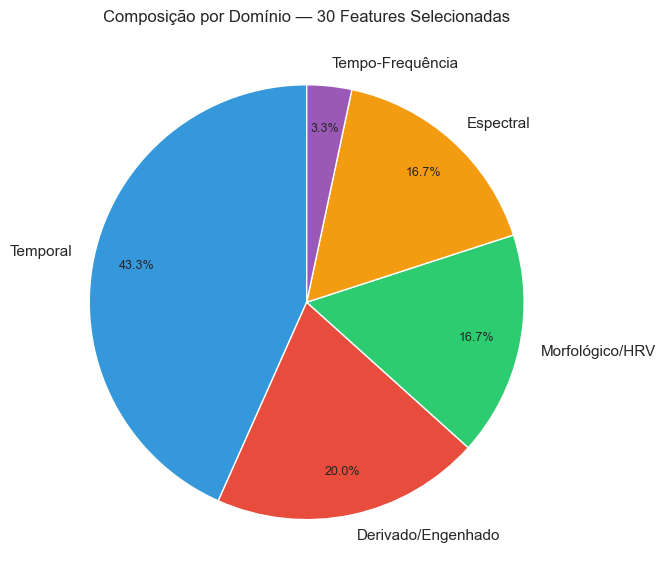

In [93]:
# Gráfico de composição por domínio — pizza

composicao = df_sel_final['dominio'].value_counts()
cores_dom  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    composicao.values,
    labels=composicao.index,
    colors=cores_dom[:len(composicao)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.80
)
for t in autotexts: t.set_fontsize(9)
ax.set_title(f'Composição por Domínio — {N_FEATURES_FINAL} Features Selecionadas', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_composicao_dominio.png', dpi=150, bbox_inches='tight')
plt.show()


### **Comentários sobre a subseção 8.1 — Subconjunto Final de Features**

O subconjunto final foi composto por 30 features selecionadas a partir do ranking consolidado obtido pelo Borda Count ponderado. O critério adotado priorizou features consistentemente bem avaliadas entre múltiplos métodos de seleção, combinando desempenho discriminativo, estabilidade entre modelos e relevância estatística.

A composição do subconjunto final revelou predominância de features do domínio temporal (13 features), seguidas por atributos derivados/engenheirados (6), morfológicos/HRV (5) e espectrais (5). Apenas uma feature de tempo-frequência permaneceu no conjunto final. Esse resultado sugere que, para o problema estudado, informações relacionadas à morfologia temporal e às distribuições estatísticas do sinal carregam maior poder discriminativo do que representações mais complexas em múltiplos domínios.

As features temporais mais relevantes foram principalmente métricas de assimetria (`time_skew_*`), curtose (`time_kurt_*`), variância (`time_var_*`) e amplitude média (`time_mav_*`). Isso indica que alterações estruturais na distribuição temporal do ECG possuem forte associação com as classes clínicas do dataset.

Entre as features morfológicas, destacaram-se principalmente amplitudes de onda T (`morph_t_amp_*`) e medidas relacionadas ao complexo QRS (`morph_qrs_width_*` e `morph_r_amp_*`). A forte presença dessas features é fisiologicamente coerente, uma vez que alterações morfológicas do ECG frequentemente refletem diretamente patologias cardíacas relevantes.

As features espectrais selecionadas concentraram-se majoritariamente em potência espectral (`freq_pt_power_*`, `freq_qrs_power_*`, `freq_total_power_*`) e centróide espectral (`freq_centroid_*`). Embora menos dominantes que as temporais, essas features demonstraram complementaridade importante no ranking consolidado.

Do ponto de vista estatístico, o subconjunto final apresentou excelente robustez:

* 19 das 30 features exibiram effect size classificado como “Grande”;
* as 11 restantes apresentaram effect size “Médio”;
* nenhuma feature com efeito pequeno ou negligenciável foi mantida.

Isso demonstra que o critério final não preservou apenas significância estatística, mas também relevância prática substancial entre as classes do problema.

Outro aspecto importante é que muitas das features finais aparecem simultaneamente entre os melhores ranks de múltiplos métodos independentes (filters, wrappers, embedded e effect size). Essa convergência aumenta significativamente a confiabilidade do subconjunto final e reduz a probabilidade de seleção baseada em artefatos específicos de um único algoritmo.

O subconjunto obtido representa, portanto, um equilíbrio entre:

* capacidade discriminativa,
* robustez estatística,
* interpretabilidade fisiológica,
* e viabilidade computacional para treinamento dos classificadores subsequentes.


### 8.2 Boxplots das Features Selecionadas por Classe

Para uma última verificação visual da separabilidade das features selecionadas, geramos boxplots das distribuições por classe das top-12 features do ranking final. Esse gráfico é especialmente útil para identificar quais classes são mais facilmente separadas pela feature e se há outliers extremos que possam impactar os classificadores.


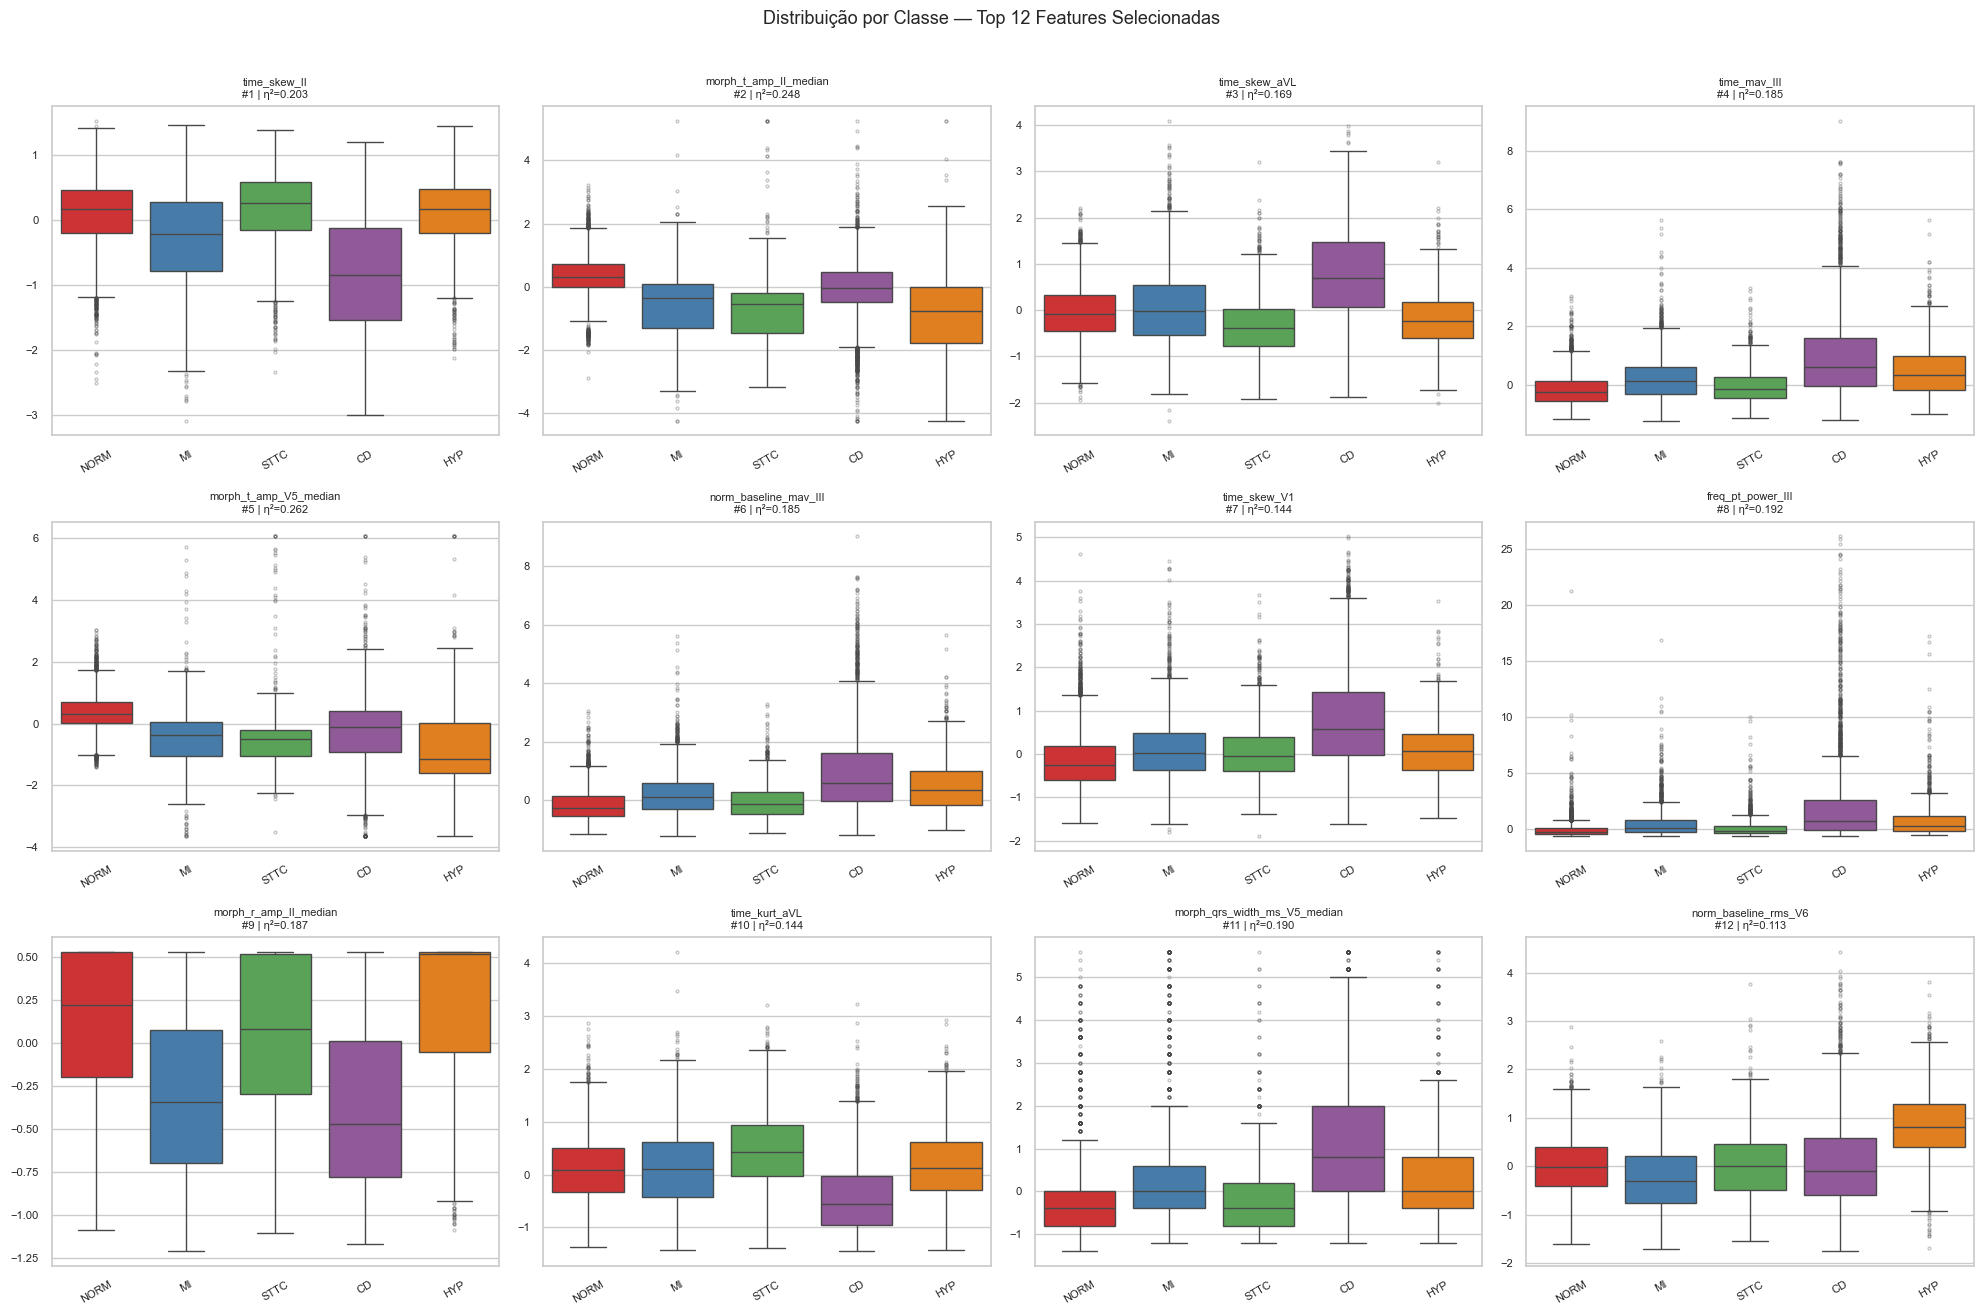

In [94]:
# Boxplots das top-12 features selecionadas por classe

top12 = features_finais[:12]
df_box_plot = df_treino[df_treino['primary_class'].isin(classes_ok)].copy()

fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

palette_cls = dict(zip(classes_ok, sns.color_palette('Set1', len(classes_ok))))

for i, feat in enumerate(top12):
    ax = axes[i]
    sns.boxplot(
        data=df_box_plot, x='primary_class', y=feat,
        order=classes_ok, hue='primary_class',
        palette=palette_cls, legend=False,
        flierprops={'markersize': 2, 'alpha': 0.3},
        ax=ax
    )
    rank_str = f'#{df_sel_final.loc[df_sel_final["feature"]==feat, "posicao_final"].values[0]}'
    eta_str  = f'η²={df_sel_final.loc[df_sel_final["feature"]==feat, "eta_squared"].values[0]:.3f}'
    ax.set_title(f'{feat}\n{rank_str} | {eta_str}', fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)
    ax.set_xticklabels(classes_ok, rotation=30, fontsize=8)

plt.suptitle('Distribuição por Classe — Top 12 Features Selecionadas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sel_boxplots_top12.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Impressão textual interpretável dos boxplots

for feat in top12:

    eta = (
        df_sel_final.loc[
            df_sel_final['feature'] == feat,
            'eta_squared'
        ]
        .values[0]
    )

    rank = (
        df_sel_final.loc[
            df_sel_final['feature'] == feat,
            'posicao_final'
        ]
        .values[0]
    )

    print()
    print('=' * 100)
    print(f'FEATURE: {feat}')
    print(f'Ranking final: #{rank}')
    print(f'Efeito: η² = {eta:.4f}')
    print('=' * 100)

    sub = df_box_stats[df_box_stats['feature'] == feat]

    for _, row in sub.iterrows():

        print(
            f'{row["classe"]:>10} | '
            f'Med={row["mediana"]:.4f} | '
            f'IQR=[{row["Q1"]:.4f}, {row["Q3"]:.4f}] | '
            f'μ={row["media"]:.4f} ± {row["std"]:.4f} | '
            f'Outliers={int(row["outliers"])} ({row["outliers_%"]:.1f}%)'
        )


FEATURE: time_skew_II
Ranking final: #1
Efeito: η² = 0.2027
        CD | Med=-0.8550 | IQR=[-1.5368, -0.1155] | μ=-0.8318 ± 0.8554 | Outliers=0 (0.0%)
       HYP | Med=0.1760 | IQR=[-0.1947, 0.4769] | μ=0.0886 ± 0.5897 | Outliers=48 (3.7%)
        MI | Med=-0.2097 | IQR=[-0.7837, 0.2752] | μ=-0.3056 ± 0.7606 | Outliers=11 (0.5%)
      NORM | Med=0.1683 | IQR=[-0.2037, 0.4569] | μ=0.0908 ± 0.5156 | Outliers=100 (1.7%)
      STTC | Med=0.2619 | IQR=[-0.1523, 0.5805] | μ=0.1573 ± 0.5976 | Outliers=46 (2.9%)

FEATURE: morph_t_amp_II_median
Ranking final: #2
Efeito: η² = 0.2478
        CD | Med=-0.0372 | IQR=[-0.4915, 0.4603] | μ=-0.1361 ± 1.0469 | Outliers=297 (9.3%)
       HYP | Med=-0.7734 | IQR=[-1.7986, -0.0157] | μ=-0.8918 ± 1.1972 | Outliers=5 (0.4%)
        MI | Med=-0.3678 | IQR=[-1.3150, 0.0903] | μ=-0.4918 ± 0.9194 | Outliers=13 (0.6%)
      NORM | Med=0.3194 | IQR=[-0.0214, 0.7283] | μ=0.3724 ± 0.6313 | Outliers=213 (3.7%)
      STTC | Med=-0.5446 | IQR=[-1.4656, -0.2057] | μ=-

**Comentários sobre os boxplots das Top-12 Features Selecionadas**

Os boxplots reforçam visualmente aquilo que já havia sido sugerido pelos rankings consolidados e pelos valores de efeito estatístico (η²): existe um subconjunto relativamente consistente de features capaz de separar grupos clínicos específicos do conjunto normal, especialmente através de diferenças de assimetria temporal (*skewness*), energia espectral e amplitudes morfológicas da onda T e do QRS.

De maneira geral, as features mais bem posicionadas apresentam pelo menos uma destas características:

* deslocamento claro das medianas entre classes;
* baixa sobreposição interquartil (IQR) entre grupos específicos;
* estabilidade estatística (baixa dispersão relativa);
* comportamento fisiologicamente interpretável.


**1. Predominância das features temporais**

As features temporais dominaram o subconjunto final (13 das 30 features), e os boxplots ajudam a explicar o motivo.

Features como:

* `time_skew_II`
* `time_skew_aVL`
* `time_skew_V1`
* `time_kurt_aVL`
* `time_mav_III`

mostram deslocamentos sistemáticos das distribuições entre as classes.

**`time_skew_II` — Melhor feature do ranking consolidado**

A feature mais forte do pipeline inteiro apresentou excelente separabilidade:

* Classe `CD` possui mediana fortemente negativa (`-0.855`);
* Classes `HYP`, `NORM` e `STTC` concentram-se próximas ou acima de zero.

Isso sugere uma alteração consistente na assimetria temporal do sinal na derivação II para pacientes CD.

Além disso:

* baixa taxa de outliers;
* IQR relativamente compacto;
* η² = 0.2027 (efeito grande).

O fato de quatro métodos independentes concordarem sobre essa feature é coerente com o comportamento observado nos boxplots.

**`time_skew_aVL`**

Também apresentou separação extremamente clara:

* `CD` possui mediana fortemente positiva;
* `STTC` apresenta tendência negativa;
* `NORM` permanece próximo do centro.

Esse comportamento indica que a assimetria temporal na derivação aVL carrega informação discriminativa importante relacionada à morfologia global do ECG.

Interessante notar que:

* há mudança de sinal entre classes;
* a separação é estrutural, não apenas de amplitude.

Isso costuma ser um indício forte de relevância fisiológica.

**`time_mav_III`**

A MAV temporal da derivação III mostrou:

* maiores amplitudes para `CD`;
* valores progressivamente menores em `MI`, `STTC` e `NORM`.

Isso sugere alteração global de energia/amplitude do sinal nessa derivação.

Mesmo com maior dispersão e alguns outliers, a tendência central permanece muito consistente entre grupos.

**2. Features morfológicas da onda T foram extremamente fortes**

As duas features morfológicas mais importantes foram:

* `morph_t_amp_II_median`
* `morph_t_amp_V5_median`

Ambas apresentaram os maiores valores de η² de toda a seleção:

* 0.2478
* 0.2618

respectivamente.

**Interpretação fisiológica importante**

As classes:

* `HYP`
* `STTC`
* `MI`

apresentam medianas claramente mais negativas que `NORM`.

Isso é extremamente plausível clinicamente.

Alterações de amplitude e polaridade da onda T frequentemente refletem:

* alterações de repolarização ventricular;
* isquemia;
* sobrecarga ventricular;
* distúrbios de condução.

Ou seja: o pipeline conseguiu recuperar automaticamente um marcador clássico da cardiologia.

Isso fortalece muito a interpretabilidade do modelo.

**3. Features espectrais mostraram boa discriminação global**

A feature:

* `freq_pt_power_III`

teve comportamento particularmente interessante.

Apesar da alta dispersão:

* `CD` apresentou potência espectral significativamente maior;
* `NORM` ficou concentrado próximo de zero.

Isso sugere aumento de energia em bandas específicas do ECG em determinadas patologias.

**Dispersão alta $\neq$ feature ruim**

Mesmo com muitos outliers:

* η² permaneceu alto (0.1921);
* a tendência central permaneceu estável.

Isso mostra que a feature captura heterogeneidade fisiológica real — algo esperado em sinais cardíacos patológicos.

**4. Features derivadas/normalizadas ajudaram muito**

Features como:

* `norm_baseline_mav_III`
* `norm_baseline_rms_V6`
* `ratio_qrs_total_V1`
* `delta_amp_II_aVL`

mostram que transformações relativas entre derivações e normalizações também carregam forte informação discriminativa.

Isso é importante porque:

* reduz dependência de escala absoluta;
* aumenta robustez interpaciente;
* captura relações espaciais entre derivações.

**`delta_amp_II_aVL`**

Mesmo aparecendo mais abaixo no ranking final, ela possui comportamento extremamente interessante:

* consenso forte entre Filter, RF e Wrapper;
* η² elevado;
* interpretação fisiológica intuitiva.

Diferenças inter-derivações frequentemente refletem alterações de eixo elétrico cardíaco.

**5. Algumas features apresentaram separação parcial, mas ainda relevante**

Nem todas as features do Top-12 separaram perfeitamente as classes.

Exemplos:

* `norm_baseline_rms_V6`
* `time_skew_V1`

apresentam:

* sobreposição significativa;
* porém deslocamentos consistentes das medianas.

Isso é esperado em problemas multiclasses reais.

Uma feature não precisa separar sozinha todas as classes; ela apenas precisa adicionar informação útil ao espaço multidimensional do classificador.

**6. Robustez geral dos boxplots**

Um ponto muito positivo foi:

**baixa incidência de outliers extremos**

A maioria das features apresentou:

* menos de 5% de outliers;
* distribuições relativamente estáveis;
* IQRs compactos.

Isso sugere que:

* o pipeline de normalização foi eficiente;
* os filtros de qualidade do sinal funcionaram adequadamente;
* as features possuem boa estabilidade estatística.

**7. Evidência forte de coerência metodológica**

Os boxplots ajudam a validar retrospectivamente os métodos de seleção.

As features mais consensuais entre:

* Filter
* LASSO
* RF
* Wrapper
* η²

são justamente aquelas que visualmente apresentam:

* maior separação de medianas;
* menor sobreposição;
* padrões fisiológicos coerentes.

Ou seja:

o ranking consolidado não parece arbitrário nem dependente de um único método.

Há convergência entre:

* estatística univariada;
* seleção multivariada;
* importância supervisionada;
* inspeção visual.

Isso fortalece bastante a credibilidade do subconjunto final selecionado.


### 8.3 Salvamento dos Artefatos


In [97]:
# Constrói o dataset final com features selecionadas + metadados

df_selected = df[META_COLS].copy()
df_selected[features_finais] = scaler.transform(df[feature_cols].values)[:, [feature_cols.index(f) for f in features_finais]]

# Salva como parquet — formato padrão do pipeline
df_selected.to_parquet(OUT_DIR / 'features_selected.parquet', index=True)

# Tabela de features selecionadas — útil para documentação e relatório
df_sel_final.to_csv(OUT_DIR / 'features_selected_ranking.csv', index=False)

# Pipeline serializado — necessário para aplicar o mesmo processamento em novos dados
pipeline_sel = {
    'scaler'          : scaler,
    'features_originais': feature_cols,
    'features_selecionadas': features_finais,
    'n_features_final': len(features_finais),
    'metadados_selecao': {
        'metodo_ranking'    : 'Borda Count ponderado (Filter + LASSO + RF + Wrapper + Effect Size)',
        'criterio_corte'    : f'Top-{N_FEATURES_FINAL} com FDR-BH < 0.05',
        'n_candidatas_avaliadas': len(candidatas),
        'n_significativas_fdr': int(df_kw["sig_fdr"].sum()),
    }
}
joblib.dump(pipeline_sel, OUT_DIR / 'feature_selection_pipeline.pkl')

print('Arquivos gerados com sucesso:')
print('-' * 55)
print(f'Dataset selecionado    : features_selected.parquet')
print(f'  - Dimensão           : {df_selected.shape[0]} registros × {len(features_finais)} features')
print()
print(f'Ranking de features    : features_selected_ranking.csv')
print(f'  - Features ranqueadas: {len(df_sel_final)}')
print()
print(f'Pipeline serializado   : feature_selection_pipeline.pkl')
print('-' * 55)


Arquivos gerados com sucesso:
-------------------------------------------------------
Dataset selecionado    : features_selected.parquet
  - Dimensão           : 17744 registros × 30 features

Ranking de features    : features_selected_ranking.csv
  - Features ranqueadas: 30

Pipeline serializado   : feature_selection_pipeline.pkl
-------------------------------------------------------


### 8.4 Síntese e Conexão com o Entregável de RP

#### O que foi feito neste entregável

| Etapa                                       | Resultado                                                        |
| ------------------------------------------- | ---------------------------------------------------------------- |
| ANOVA F-score                               | Ranking inicial de separação linear entre classes                |
| Informação Mútua                            | Captura de dependências não-lineares entre feature e classe      |
| ReliefF                                     | Avaliação baseada em vizinhança entre instâncias                 |
| Síntese Filter — Borda Count                | Consolidação dos três métodos de filtro em um ranking único      |
| Sequential Forward Selection (SFS)          | Subconjunto incremental baseado em ganho de performance          |
| Sequential Backward Elimination (SBE)       | Subconjunto por remoção iterativa de features                    |
| Interseção SFS ∩ SBE                        | Núcleo de features consistentes entre abordagens wrapper         |
| LASSO (LogisticRegressionCV L1)             | Seleção embutida via regularização esparsa                       |
| Random Forest Importance                    | Ranking baseado em ganho de impureza                             |
| Kruskal–Wallis por feature                  | Teste não-paramétrico de diferença entre classes                 |
| Correção FDR-BH                             | Controle de múltiplas comparações e controle de falsos positivos |
| Eta-quadrado (η²)                           | Medida de efeito para relevância prática das features            |
| Ranking final — Borda Count ponderado       | Agregação final dos métodos em um score único                    |
| Dataset final (`features_selected.parquet`) | Subconjunto final pronto para modelagem supervisionada           |

#### Limitações

- Todos os rankings foram calculados sobre o conjunto de treino (folds 1–8). As estimativas podem apresentar algum grau de variância amostral, especialmente para o ReliefF e os wrappers, que operam sobre amostras menores.

- O Borda Count ponderado é um método de agregação heurístico. Pesos diferentes para cada método produziriam subconjuntos diferentes. Essa escolha deve ser validada empiricamente pelos modelos no Entregável de RP.

- O LASSO e o RF capturam relações que os filtros não capturam, mas são sensíveis a hiperparâmetros. A robustez dos resultados pode ser verificada com diferentes valores de $C$ (LASSO) e `n_estimators` / `max_depth` (RF).

- A análise de effect size ($\eta^2$) assume que diferenças entre medianas são um proxy razoável de relevância clínica. Para problemas onde a forma da distribuição é importante (ex: bimodalidade), essa métrica pode ser insuficiente.

---

#### Próximos passos — Entregável de RP

O `features_selected.parquet` está pronto para entrada nos classificadores. A partir daqui, o experimento segue dois paradigmas complementares já definidos no pipeline:

1. **Seleção supervisionada (este entregável):**
   Modelos treinados sobre as **30 features selecionadas**, todas interpretáveis e associadas a significados fisiológicos diretos. Esse cenário privilegia interpretabilidade e análise clínica dos resultados.

2. **Compressão via PCA (Entregável 8):**
   Modelos treinados sobre os **79 componentes principais fixos**, obtidos por transformação linear das features originais. Esse cenário privilegia compactação e desempenho potencial, mas sem interpretabilidade direta por componente.

A comparação entre esses dois espaços de representação — **features selecionadas vs. espaço latente do PCA (79 dimensões)** — permite avaliar o trade-off entre interpretabilidade e capacidade discriminativa dos modelos, sendo um dos pontos centrais da análise experimental do Entregável de RP.

In [98]:
# Tabela resumo final

print('=' * 60)
print('   VERIFICAÇÃO FINAL — ENTREGÁVEL 9')
print('=' * 60)
print(f'  Features originais (E7)       : {len(feature_cols)}')
print(f'  Candidatas avaliadas          : {len(candidatas)}')
print(f'  Significativas (FDR-BH < 5%) : {int(df_kw["sig_fdr"].sum())}')
print(f'  Features selecionadas (final) : {len(features_finais)}')
print(f'  Redução                       : {(1 - len(features_finais)/len(feature_cols))*100:.1f}%')
print()
print('  Composição do subconjunto final:')
for dom, n in df_sel_final['dominio'].value_counts().items():
    print(f'    {dom:<25} : {n} features')
print()
print('  Artefatos gerados:')
print('    - features_selected.parquet')
print('    - features_selected_ranking.csv')
print('    - feature_selection_pipeline.pkl')
print()
print('  Dataset pronto para o Entregável de RP.')
print('=' * 60)


   VERIFICAÇÃO FINAL — ENTREGÁVEL 9
  Features originais (E7)       : 282
  Candidatas avaliadas          : 127
  Significativas (FDR-BH < 5%) : 127
  Features selecionadas (final) : 30
  Redução                       : 89.4%

  Composição do subconjunto final:
    Temporal                  : 13 features
    Derivado/Engenhado        : 6 features
    Morfológico/HRV           : 5 features
    Espectral                 : 5 features
    Tempo-Frequência          : 1 features

  Artefatos gerados:
    - features_selected.parquet
    - features_selected_ranking.csv
    - feature_selection_pipeline.pkl

  Dataset pronto para o Entregável de RP.
